## Pre-Installations

In [1]:
!pip install evaluate langchain_text_splitters langchain_community langchain_core pypdf faiss-cpu langchain_openai ragas yfinance wandb peft openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.5/329.5 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.1/397.1 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.9/160.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.8/358.8 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.

## Imports

In [2]:
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.tools import tool
import yfinance as yf
import pandas as pd
import joblib
import json
import os
import importlib
import re
import sys
import random
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from tqdm import tqdm
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from datetime import datetime
from typing import Literal
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from scipy.stats import f_oneway
import warnings
from typing import List, Dict, Any
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import context_precision, context_recall, faithfulness

warnings.filterwarnings('ignore')

from dotenv import load_dotenv
import faiss
load_dotenv()


False

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from sklearn.linear_model import LinearRegression
from operator import itemgetter
from typing import Dict, Any, Optional
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import OpenAIEmbeddings
from langchain_openai import ChatOpenAI


In [4]:
import random
import logging
import wandb
from __future__ import annotations

import torch
import datasets
import datasets
from dataclasses import dataclass
from typing import Dict, List


import torch
from datasets import load_dataset
import transformers
from transformers import (
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    HfArgumentParser,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    pipeline,
    logging,
    DataCollatorForLanguageModeling,
)
from peft import LoraConfig, PeftModel, get_peft_model
from evaluate import load
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


In [5]:
from google.colab import drive
import os

# Ensure the mount point is empty before mounting
if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
    # Only remove contents if it's a directory and not already mounted
    # A safer approach is to check if it's a mount point first, but for Colab,
    # simply clearing it before mounting is usually sufficient if it's not mounted.
    if not os.path.ismount('/content/drive'):
        !rm -rf /content/drive/*

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Clustering Customer Segments

In [6]:
SAVED_MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/results'


In [7]:
personal_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/personal_finance_tracker_dataset.csv')
print(personal_df.shape)
personal_df.head()

(3000, 25)


,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,discretionary_spending,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met
0,2019-01-01,1584,3119.58,3212.07,0.38,3676.11,inflation,721.0,0.56,125.77,...,857.55,1910.85,Freelance,1501.65,Investments,Positive,8.3,Low,0.00,0
1,2019-01-31,1045,3262.44,3732.81,0.10,2607.17,inflation,670.0,0.42,454.19,...,534.51,3165.20,Salary,1603.17,Investments,Positive,22.6,Low,0.00,0
2,2019-03-02,1756,2931.20,3335.58,0.15,3004.14,inflation,691.0,0.24,971.82,...,353.67,1504.56,Freelance,1097.82,Healthcare,Positive,58.8,Low,0.00,0
3,2019-04-01,1724,3506.79,2327.59,0.17,3346.97,normal,717.0,0.16,482.76,...,594.08,1450.72,Freelance,1155.64,Groceries,Positive,74.5,Low,1179.20,0
4,2019-05-01,1600,4606.87,2182.58,0.34,2670.09,inflation,795.0,0.25,263.74,...,556.86,1000.00,Salary,1170.86,Utilities,Negative,38.7,High,2424.29,0


In [8]:
num_features = ['monthly_income',
 'monthly_expense_total',
 'savings_rate',
 'budget_goal',
 'credit_score',
 'debt_to_income_ratio',
 'loan_payment',
 'investment_amount',
 'emergency_fund',
 'transaction_count',
 'discretionary_spending',
 'essential_spending',
 'rent_or_mortgage',
 'financial_advice_score',
 'actual_savings']

cat_features = [
 'financial_scenario',
 'subscription_services',
 'income_type',
 'category',
 'cash_flow_status',
 'financial_stress_level',
 'savings_goal_met']

print(f"Number of Numerical Features: {len(num_features)}")
print(f"Number of Categorical features: {len(cat_features)}")

Number of Numerical Features: 15
Number of Categorical features: 7


In [9]:
train, test = train_test_split(personal_df, test_size=0.2, random_state=42)

### Exploratory Data Analysis

In [10]:
missing_counts = train.isnull().sum()
missing_count_percent = (missing_counts / len(train)) * 100
missing_data = pd.DataFrame({'Missing Count': missing_counts, 'Missing Percentage': missing_count_percent})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

if not missing_data.empty:
	missing_data.plot.bar(y='Missing Percentage', title='Missing Data Percentage by Column', figsize=(18, 10))
else:
	print("No missing data found in the DataFrame.")

No missing data found in the DataFrame.


In [11]:
missing_num = ['monthly_income', 'credit_score', 'monthly_expense_total']

def fill_missing_value(df, missing_num):
    for col in missing_num:
        if col in df.columns:
            median_value = df[col].median()
            df[col].fillna(median_value, inplace=True)

# Apply to train and test DataFrames
fill_missing_value(train, missing_num)
fill_missing_value(test, missing_num)


In [12]:
# Feature engineering
new_features = ['spending_ratio','investment_ratio']
def create_features(df):
    df['savings_rate'] = round(df['actual_savings'] / df['monthly_income'],2)
    df['spending_ratio'] = (df['essential_spending'] + df['discretionary_spending']) / df['monthly_income']
    df['investment_ratio'] = df['investment_amount'] / df['monthly_income']
    df['debt_to_income_ratio'] = df['loan_payment'] / df['monthly_income']

    return df

train = create_features(train)
test = create_features(test)

num_features = num_features + new_features

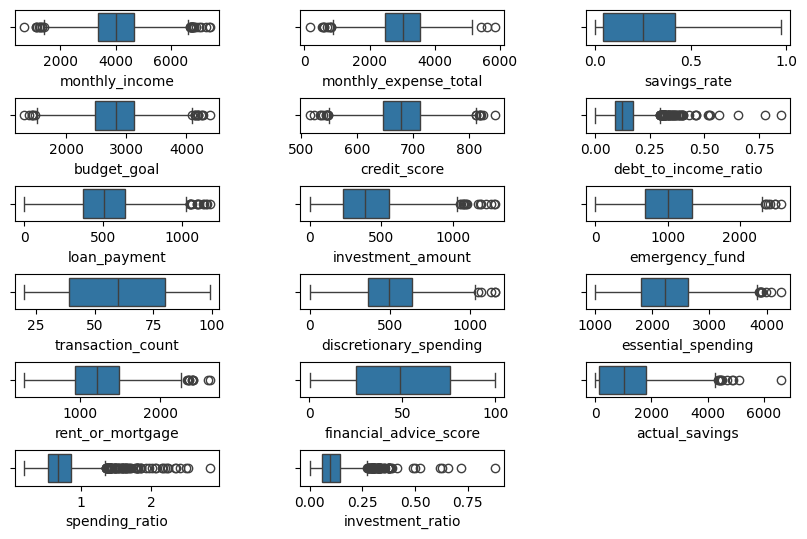

In [13]:
# Box plot to detect outliers
fig, ax = plt.subplots(7,3, figsize=(10,6))
plt.subplots_adjust(top = 0.99, bottom=0.05, hspace=1.5, wspace=0.4)
ax = ax.flatten()
for i,col in enumerate(num_features):
    sns.boxplot(x=train[col], ax=ax[i])
    #ax[i].set_title(f'Boxplot for {col}')

# Hide any remaining axes if num_features < 9
for j in range(len(num_features), len(ax)):
    ax[j].set_visible(False)

plt.show()

<Axes: title={'center': 'Outlier Percentage by Column'}, xlabel='feature'>

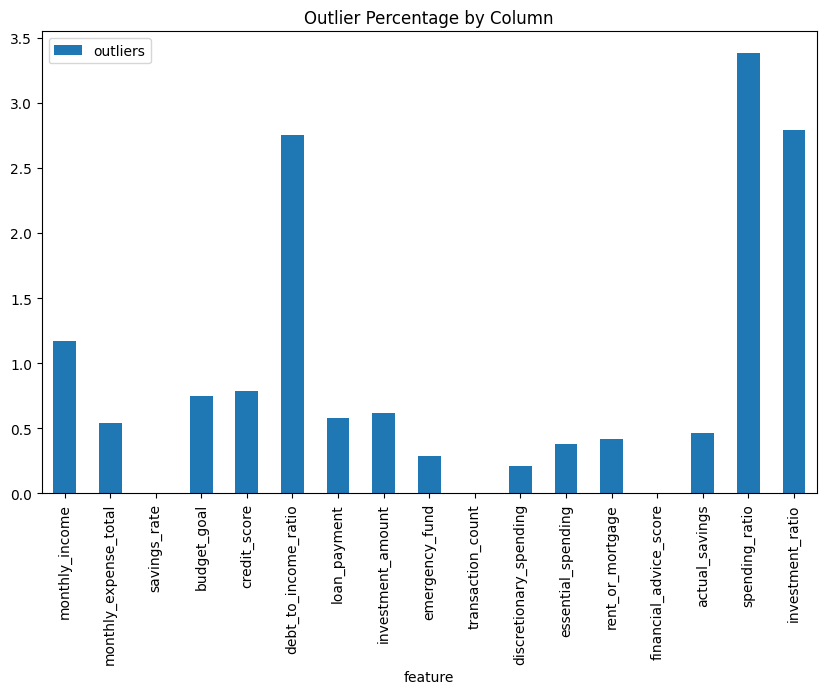

In [14]:
# detect outliers
def detect_outliers(df, num_features):
    outlier_df = pd.DataFrame(columns=['feature','outliers'])
    for col in num_features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)]
        outlier_perc = round(len(outliers) / len(df) * 100, 2)
        new_row = pd.DataFrame([{'feature': col, 'outliers': outlier_perc}])
        outlier_df = pd.concat([outlier_df, new_row], ignore_index=True)
    return outlier_df

outlier_df = detect_outliers(train, num_features)
#missing_data.plot.bar(y='Missing Percentage', title='Missing Data Percentage by Column', figsize=(18, 10))
outlier_df.set_index('feature').plot.bar(y='outliers', title='Outlier Percentage by Column', figsize=(10, 6))

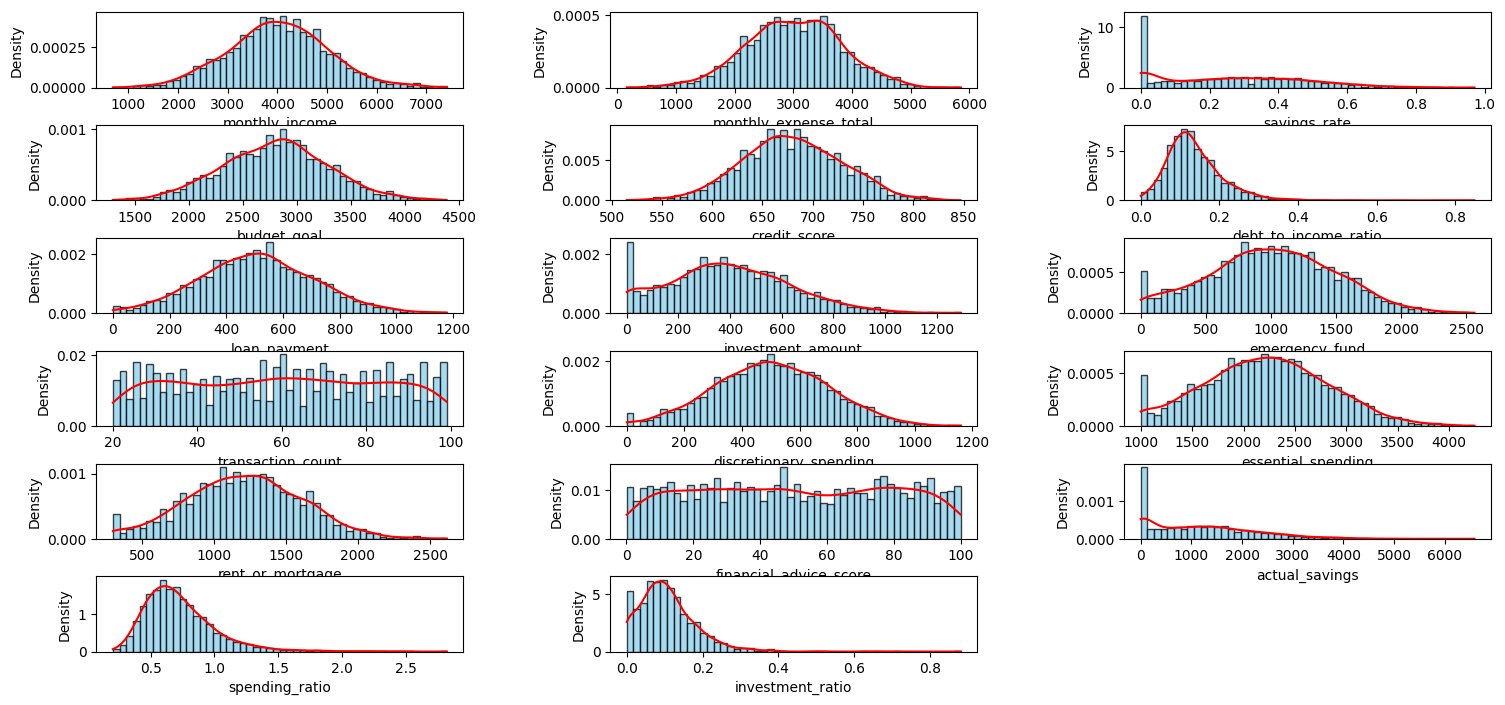

In [15]:
# create histogram with KDE plot for all teh numerical features
def plot_feature_distribution(df):
    fig, ax = plt.subplots(7, 3, figsize=(18, 8))
    plt.subplots_adjust(top = 0.99, bottom=0.05, hspace=0.5, wspace=0.4)
    ax = ax.flatten()
    for i,col in enumerate(num_features):
        #print(f'{base_smote[col].skew()}~{col}')
        # Check if the column is numeric before applying KDE
        if df[col].dtype in [np.int64, np.float64]:
            kde = stats.gaussian_kde(df[col])
            x = np.linspace(df[col].min(), df[col].max(), 1000)
            ax[i].plot(x, kde(x), color='red')
            ax[i].hist(df[col], bins=50, density=True, alpha=0.75, color='skyblue', edgecolor='black')
            #ax[i].set_title(f'{col}')
            ax[i].set_xlabel(col)
            ax[i].set_ylabel('Density')
        else:
            print(f"Skipping non-numeric column: {col}") # Inform the user about skipped columns

    # Hide any remaining axes if num_features < 9
    for j in range(len(num_features), len(ax)):
        ax[j].set_visible(False)

plot_feature_distribution(train)

Based on the outlier count and the feature distribution, following are the rationale behind each pre-processing.  
    
1. Monthly Income - No change as there can be high income earners.
2. Montly Expense - No change as there can be high spenders.  
3. Savings habit - Different savings habit, but highly left skewed. Perform log transformation.  
4. budget_goal - Some extremes goal setters can skew centroids. Clip extreme values.    
5. Credit score - Clip to 300-850 scale.   
6. debt income ratio - Clip extreme debtors.  
7. loan payment - slightly right skewed. winsorize extreme values.  
8. Investment amount - Heavily right skewed - Perform log transformation.  
9. emergency fund - mildly skewed. Perform log transformation.  
10. Rent or mortgage - Winsorize extreme values.
11. actual savings - Extreme savers exist. perform log1p.  
12. Investment ratio - Clip extreme values.  
13. Spending ratio - Clip extreme values.  



In [16]:
def winsorize(series, lower=0.01, upper=0.99):
    #Clip (winsorize) values at lower and upper percentiles
    return np.clip(series, series.quantile(lower), series.quantile(upper))

def safe_log1p(series):
    #Apply log1p safely (handles zeros or negatives)
    return np.log1p(np.where(series < 0, 0, series))

def fix_outliers(df):
    # Monthly income – nearly normal, mild tail
    df['monthly_income'] = df['monthly_income']  # keep raw

    # Monthly expense total – keep, maybe winsorize a bit
    df['monthly_expense_total'] = df['monthly_expense_total']

    # Savings rate – bounded ratio
    df['savings_rate'] = safe_log1p(df['savings_rate'])

    # Budget goal – slightly skewed, winsorize
    df['budget_goal'] = winsorize(df['budget_goal'])

    # Credit score – real-world bounds
    df['credit_score'] = np.clip(df['credit_score'], 300, 850)

    # Debt-to-income ratio – clip extreme debtors
    df['debt_to_income_ratio'] = np.clip(df['debt_to_income_ratio'], 0, 1.2)

    # Loan payment – right-skewed, winsorize
    df['loan_payment'] = winsorize(df['loan_payment'])

    # Investment amount – heavy tail, log transform
    df['investment_amount'] = safe_log1p(df['investment_amount'])

    # Actual savings – highly skewed, log transform
    df['actual_savings'] = safe_log1p(df['actual_savings'])

    # spending ratio – winsorize top end
    df['spending_ratio'] = safe_log1p(df['spending_ratio'])

    # investment ratio – winsorize top end
    df['investment_ratio'] = safe_log1p(df['spending_ratio'])

    return df

train = fix_outliers(train)
test = fix_outliers(test)

num_features = [
    'monthly_income', 'monthly_expense_total', 'savings_rate', 'budget_goal',
    'credit_score', 'debt_to_income_ratio', 'loan_payment', 'investment_amount',
    'emergency_fund', 'transaction_count', 'discretionary_spending',
    'essential_spending', 'rent_or_mortgage', 'financial_advice_score', 'actual_savings'
]



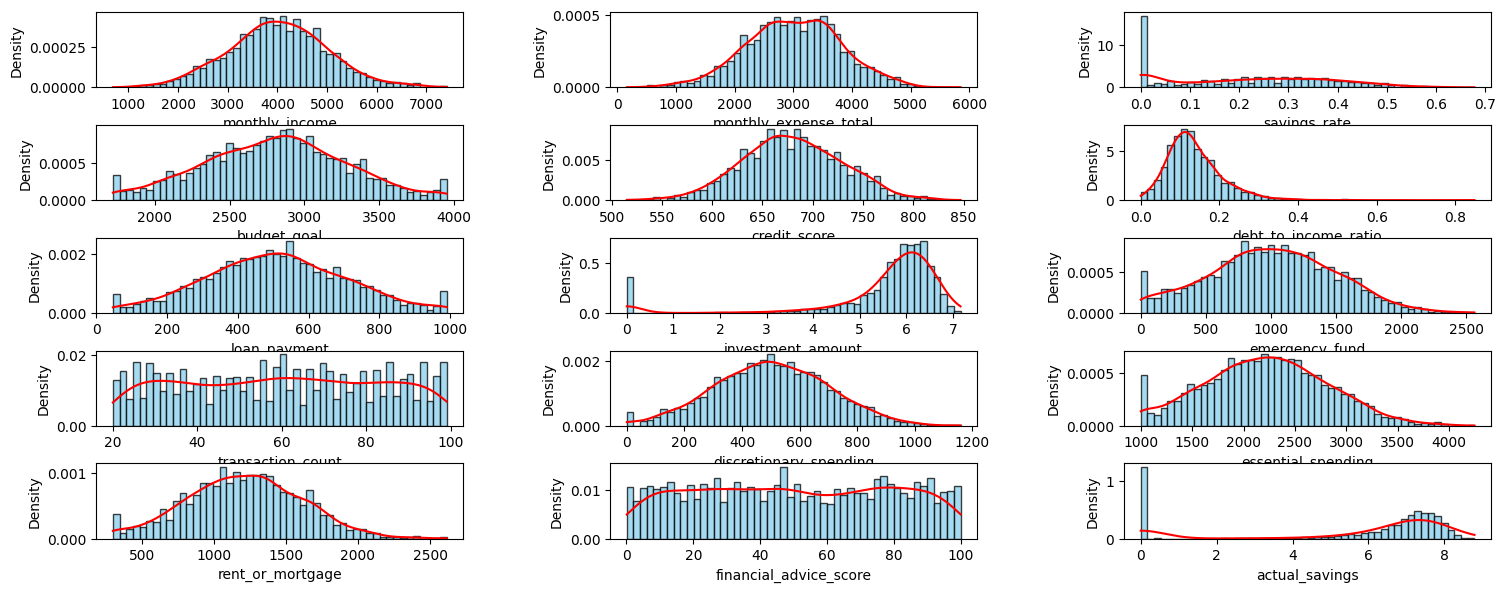

In [17]:
plot_feature_distribution(train)

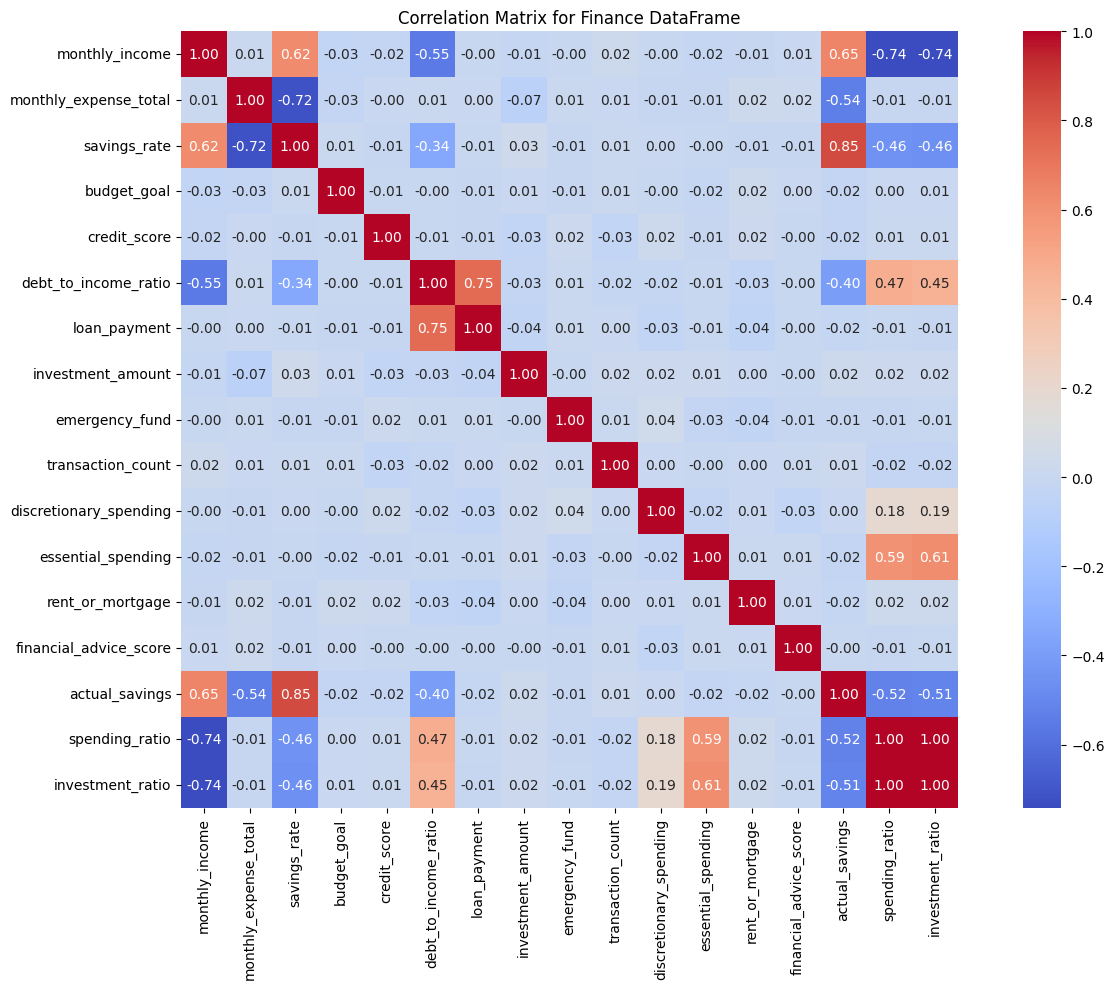

In [18]:
def plot_correlation_matrix(df, df_name="DataFrame"):
    """
    Plots a heatmap of the correlation matrix for numeric columns in the DataFrame.
    """
    corr = df.select_dtypes(include=['float64', 'int64']).corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
    plt.title(f'Correlation Matrix for {df_name}')
    plt.tight_layout()
    plt.show()

plot_correlation_matrix(train[num_features+new_features], "Finance DataFrame")

Monthly income or actual savings (0.65).   
Monthy income or savings rate (0.62).   
Monthly income or spending ratio (-0.74).   
Monthly income or investment ratio (-0.74).   
Monthly expense total or savings rate (-0.72).   
debt income ration or loan payment(0.).   
investment amount vs investment ratio (0.84).   
actual savings vs savings rate (0.85).   

In [19]:
num_features = [
    'monthly_income',
    'monthly_expense_total',
    'actual_savings',
    'debt_to_income_ratio',
    'investment_amount',
    'emergency_fund',
    'credit_score',
]


cat_features = [
 'financial_scenario',
 'subscription_services',
 'cash_flow_status',
 'financial_stress_level']

print(f"Number of Numerical Features: {len(num_features)}")
print(f"Number of Categorical features: {len(cat_features)}")

Number of Numerical Features: 7
Number of Categorical features: 4


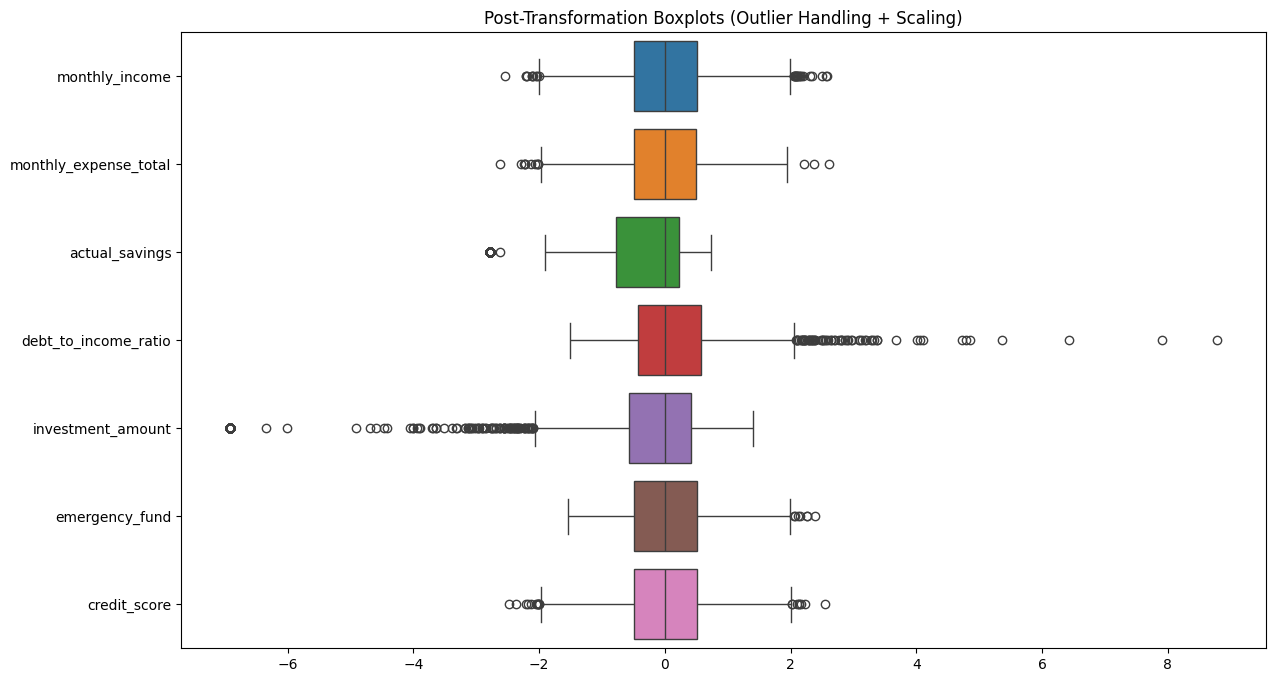

In [20]:
scaler = RobustScaler()
train[num_features] = scaler.fit_transform(train[num_features])
test[num_features] = scaler.transform(test[num_features])
joblib.dump(scaler, 'robust_scaler.pkl')

plt.figure(figsize=(14, 8))
sns.boxplot(data=train[num_features], orient='h')
plt.title("Post-Transformation Boxplots (Outlier Handling + Scaling)")
plt.show()

In [21]:
train_df = train[num_features + cat_features]
test_df = test[num_features + cat_features]

In [22]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# Fit and transform
encoded = encoder.fit_transform(train_df[cat_features])
encoded_test = encoder.transform(test_df[cat_features])

# Optionally get column names
encoded_columns = encoder.get_feature_names_out(cat_features)

# Create DataFrame
train_processed_df = pd.DataFrame(encoded, columns=encoded_columns, index=train_df.index)
test_processed_df = pd.DataFrame(encoded_test, columns=encoded_columns, index=test_df.index)


To create meaningful clusters denoting customer segments based on financial behaviors, we generate the following features:   
•	savings rate = actual savings/income.    
•	spending ratio = (essential spending + discretionary spending) / income.     
•	investment ratio = investment amount/income.     
•	debt to income = loan payment/income.     


In [23]:
train_processed_df

,financial_scenario_inflation,financial_scenario_normal,financial_scenario_recession,subscription_services_1,subscription_services_2,subscription_services_3,subscription_services_4,subscription_services_5,subscription_services_6,subscription_services_7,subscription_services_8,subscription_services_9,cash_flow_status_Negative,cash_flow_status_Neutral,cash_flow_status_Positive,financial_stress_level_High,financial_stress_level_Low,financial_stress_level_Medium
642,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
700,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
226,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1697,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1010,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1095,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1130,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1294,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [24]:
inertias = []
knn_labels = []
models = {}
silhouettes = {}

def init_dataframe(train, test, num_features):
    train_num_df = train[num_features]
    test_num_df = test[num_features]
    return train_num_df, test_num_df

# Function to perform KMeans clustering
def kmeans_clustering(data, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, n_init='auto', random_state=0)
    kmeans.fit(data)
    return kmeans, kmeans.labels_, kmeans.inertia_

def train_clusters(df, n_cluseters):
    # Perform KMeans clustering for different values of k
    df_cluster=df.copy()
    for n_cluster in range(2, n_cluseters):
        kmeans, labels, inertia = kmeans_clustering(df, n_cluster)
        inertias.append(inertia)
        knn_labels.append(labels)
        models[n_cluster] = kmeans

        # Calculate silhouette score
        silhouette_avg = silhouette_score(df, labels)
        silhouettes[n_cluster] = silhouette_avg
        print(f'Number of clusters: {n_cluster}, Inertia: {inertia}, Silhouette Score: {silhouette_avg}')

        # Add cluster labels to the DataFrame
        df_cluster[f'cluster_{n_cluster}'] = labels

        # Save each KMeans model with the cluster count in the filename
        model_path = os.path.join(SAVED_MODEL_DIR, f'kmeans_k{n_cluster}.pkl')
        joblib.dump(kmeans, model_path)

    # Pick best k by silhouette (you could also use elbow via inertia)
    best_k = max(silhouettes, key=silhouettes.get)
    best_model_path = os.path.join(SAVED_MODEL_DIR, f'kmeans_k{best_k}.pkl')

    print(f"\nBest k by silhouette: k={best_k} (score={silhouettes[best_k]:.4f})")
    print(f"Loading best model from: {best_model_path}")

    # Load the trained KMeans model (guaranteed to be a single model object)
    best_kmeans = joblib.load(best_model_path)
    print(best_model_path)
    print("KMeans names:", getattr(best_kmeans, "feature_names_in_", None))
    print(type(best_kmeans))

    return df_cluster, inertias, silhouettes, best_kmeans

def plot_k_means_elbow(n_cluseters):
    # Plot the elbow curve
    plt.plot(range(2, n_cluseters), inertias, 'bo-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('inertia')
    plt.title('Elbow Method for K values')
    plt.show()

def define_cluster_summary(df, optimal_cluster, features):
    # Choose Cluster 3 based on the elbow method
    cluster_summary = df.groupby(optimal_cluster)[features].mean().reset_index()
    return cluster_summary

# Get optimal cluster score
def get_optimal_cluster_scores(df, clusters):
    kmeans, labels, inertia = kmeans_clustering(df, clusters)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(df, labels)

    # Calculate silhouette score
    print(f'Number of clusters: {clusters}, Inertia: {inertia}, Silhouette Score: {silhouette_avg}')

    # Add cluster labels to the DataFrame
    df[f'optimal_cluster'] = labels

def plot_number_of_samples(df, cluster_summary):
    cluster_counts = df['optimal_cluster'].value_counts().sort_index()
    cluster_summary['sample_count'] = cluster_counts
    plt.bar(cluster_summary['optimal_cluster'], cluster_summary['sample_count'], color='skyblue')
    plt.xlabel('Cluster')
    plt.ylabel('Sample Count')
    plt.title('Sample Count per Cluster')
    plt.xticks(rotation=0)
    plt.show()

    return cluster_summary


def plot_PCA_scatter_plot(df):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(df)
    df['PCA1'] = X_pca[:, 0]
    df['PCA2'] = X_pca[:, 1]

    # Plot PCA Visualization using 'optimal_cluster'
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df,
        x='PCA1',
        y='PCA2',
        hue='optimal_cluster',
        palette='Set1',
        s=100,
        alpha=0.8
    )

    plt.title('PCA Scatter Plot of Financial Segment Clusters (k=3)')
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df

def plot_cluster_segments(cluster_summary, num_featues, k):
    # Plot the mean values of each feature for each cluster
    plt.figure(figsize=(10, 6))
    for i in range(k):
        plt.plot(num_features, cluster_summary.loc[i, num_features], marker='o', label=f'Cluster {i}')
    plt.title('Line Chart Comparing All Clusters')
    plt.xlabel('Features')
    plt.ylabel('Standardized Value (Z-score)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def anova_test(df, features):
    anova_results = {}
    for col in features:
        groups = [df[df["optimal_cluster"] == c][col] for c in df["optimal_cluster"].unique()]
        f_stat, p_val = f_oneway(*groups)
        anova_results[col] = {"F-statistic": f_stat, "p-value": p_val}

    anova_df = pd.DataFrame(anova_results).T
    print(anova_df.sort_values("p-value"))


Number of clusters: 2, Inertia: 13432.487771385282, Silhouette Score: 0.3751097911501347
Number of clusters: 3, Inertia: 8282.117049556175, Silhouette Score: 0.39934233298257504
Number of clusters: 4, Inertia: 7477.679848845895, Silhouette Score: 0.2010984458245932
Number of clusters: 5, Inertia: 6880.2664112143875, Silhouette Score: 0.2033488208515996
Number of clusters: 6, Inertia: 6471.6996866227255, Silhouette Score: 0.19212732867322505
Number of clusters: 7, Inertia: 6180.218657300679, Silhouette Score: 0.1880724012631099

Best k by silhouette: k=3 (score=0.3993)
Loading best model from: /content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/results/kmeans_k3.pkl
/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/results/kmeans_k3.pkl
KMeans names: ['monthly_income' 'monthly_expense_total' 'actual_savings'
 'debt_to_income_ratio' 'investment_amount' 'emergency_fund'
 'credit_score']
<class 'sklearn.cluster._kmeans.KMeans'>


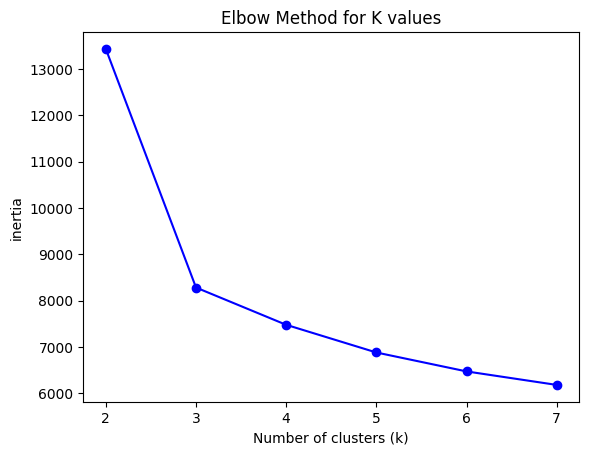

,monthly_income,monthly_expense_total,actual_savings,debt_to_income_ratio,investment_amount,emergency_fund,credit_score,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7
642,0.107450,-1.736912,0.428968,-0.360537,0.585015,0.205640,-0.227273,0,0,0,4,4,0
700,1.178565,1.074253,0.112889,-0.278602,0.599700,0.315391,-0.530303,0,0,1,0,1,1
226,0.901706,0.697374,0.126376,-0.029620,0.137334,0.096118,0.378788,0,0,1,0,0,1
1697,2.587453,0.745266,0.495741,-0.463082,-0.205033,0.648879,-0.212121,0,0,1,0,1,1
1010,-0.722608,-0.272723,-0.436757,0.234949,-1.681015,-0.991696,0.878788,0,0,0,1,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,-0.846357,0.293234,-2.777825,-0.159084,0.578132,0.756337,-0.075758,1,1,3,3,3,3
1095,0.274953,0.412136,-0.051910,0.204659,-0.202131,-0.123751,-0.242424,0,0,1,0,1,1
1130,-1.029298,1.191696,-2.777825,1.618114,-1.834053,-0.373409,-1.454545,1,1,3,3,3,3
1294,0.297428,0.461727,-0.062820,-0.320911,-0.676524,1.001437,0.227273,0,0,1,1,0,6


In [25]:
# initialize dataframes
train_num_df, test_num_df = init_dataframe(train_df, test_df, num_features)

# Perform KMeans clustering for different values of k
train_cluster, inertias, silhouettes, best_kmeans = train_clusters(train_num_df, 8)

# plot elbow for clusters
plot_k_means_elbow(8)

train_cluster

K=2: Statistically “cleanest” clustering (high silhouette = strong separation) but may oversimplify — grouping everyone into just “high vs low” type customers.  

K=3: Still good silhouette (0.55) and better granularity — often ideal for financial segmentation (e.g., low-income / mid-income / affluent).  

K=4: Matches the elbow point, offering richer behavioral separation while still reasonable cohesion.  

K>4: Both metrics worsen (clusters become less meaningful).  

In [26]:
train_cluster

,monthly_income,monthly_expense_total,actual_savings,debt_to_income_ratio,investment_amount,emergency_fund,credit_score,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7
642,0.107450,-1.736912,0.428968,-0.360537,0.585015,0.205640,-0.227273,0,0,0,4,4,0
700,1.178565,1.074253,0.112889,-0.278602,0.599700,0.315391,-0.530303,0,0,1,0,1,1
226,0.901706,0.697374,0.126376,-0.029620,0.137334,0.096118,0.378788,0,0,1,0,0,1
1697,2.587453,0.745266,0.495741,-0.463082,-0.205033,0.648879,-0.212121,0,0,1,0,1,1
1010,-0.722608,-0.272723,-0.436757,0.234949,-1.681015,-0.991696,0.878788,0,0,0,1,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,-0.846357,0.293234,-2.777825,-0.159084,0.578132,0.756337,-0.075758,1,1,3,3,3,3
1095,0.274953,0.412136,-0.051910,0.204659,-0.202131,-0.123751,-0.242424,0,0,1,0,1,1
1130,-1.029298,1.191696,-2.777825,1.618114,-1.834053,-0.373409,-1.454545,1,1,3,3,3,3
1294,0.297428,0.461727,-0.062820,-0.320911,-0.676524,1.001437,0.227273,0,0,1,1,0,6


Number of clusters: 3, Inertia: 25651.753301756722, Silhouette Score: 0.3373740621350124


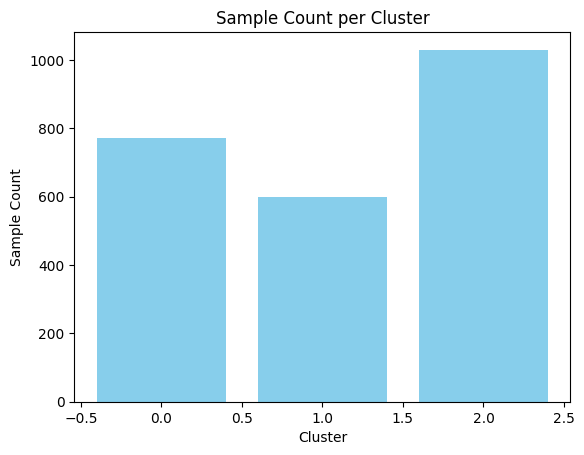

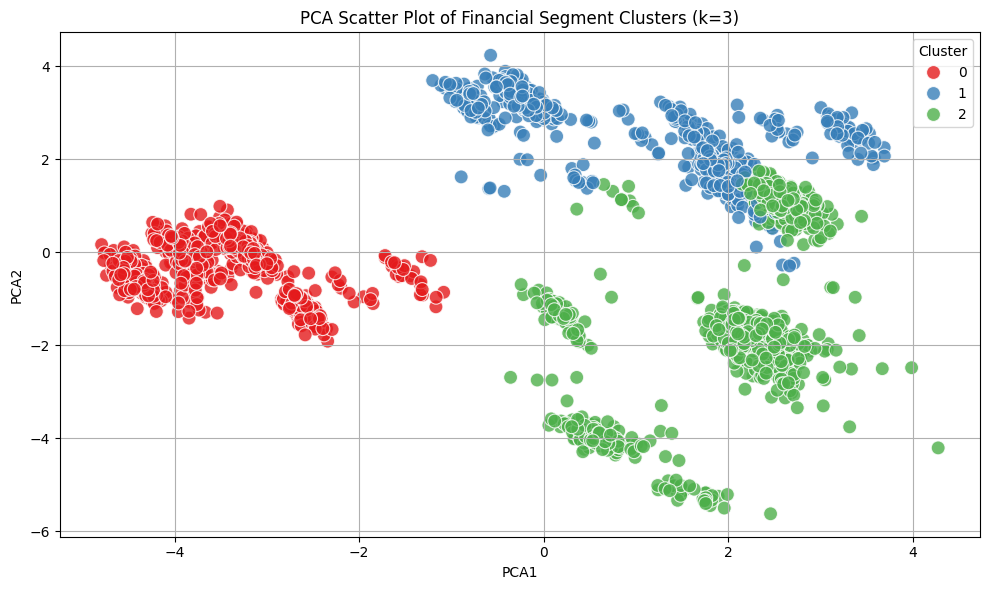

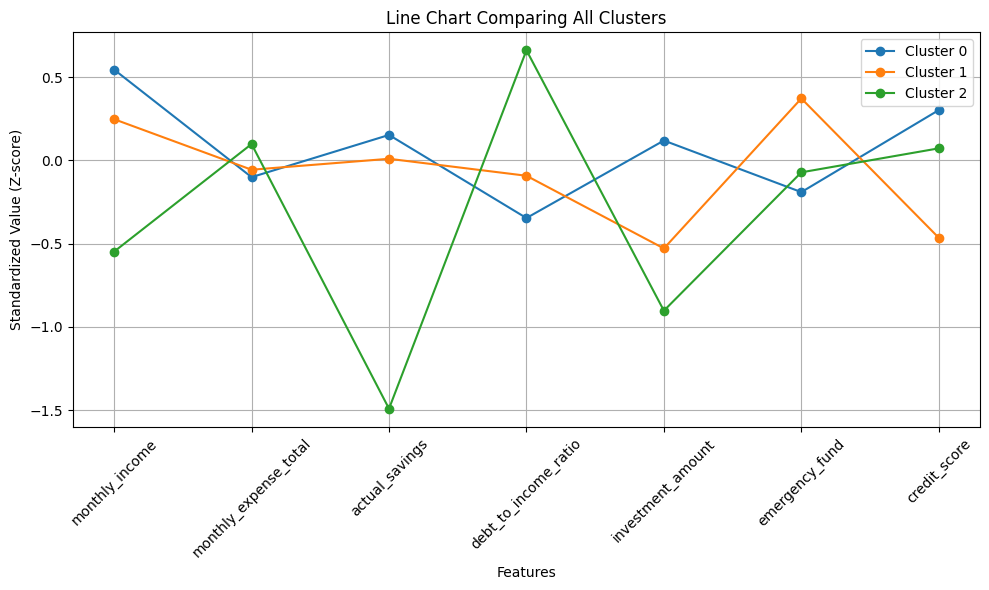

In [27]:
best_k=3
# optimal cluster scores
get_optimal_cluster_scores(train_cluster, best_k)

# define cluster summary
cluster_summary = define_cluster_summary(train_cluster, 'optimal_cluster', num_features)


# Plot number of samples per cluster
plot_number_of_samples(train_cluster, cluster_summary)


# Plot PCA scatter plot
plot_PCA_scatter_plot(train_cluster)

# Plot cluseter segments
plot_cluster_segments(cluster_summary, num_features, best_k)

In [28]:
# Apply clustering to test data
test_eval = test_num_df.copy()
test_eval['cluster'] = best_kmeans.predict(test_eval)

test_silhouette = silhouette_score(test_eval, test_eval['cluster'])
print(f'Silhouette score on test data (k={best_k}): {test_silhouette}')

Silhouette score on test data (k=3): 0.4258688595676159


In [29]:
anova_test(train_cluster, num_features)

                       F-statistic        p-value
actual_savings          879.061249  4.564742e-287
monthly_income          849.127365  1.634766e-279
debt_to_income_ratio    428.157574  1.021564e-159
credit_score            215.446536   8.989856e-87
emergency_fund          115.948207   8.582824e-49
investment_amount        82.999417   1.403367e-35
monthly_expense_total    18.274823   1.328147e-08


In [30]:
train_cluster_cat = pd.concat([train_cluster, train_df[cat_features]], axis=1)
train_cluster_cat

,monthly_income,monthly_expense_total,actual_savings,debt_to_income_ratio,investment_amount,emergency_fund,credit_score,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,optimal_cluster,PCA1,PCA2,financial_scenario,subscription_services,cash_flow_status,financial_stress_level
642,0.107450,-1.736912,0.428968,-0.360537,0.585015,0.205640,-0.227273,0,0,0,4,4,0,2,-0.054368,-0.813848,recession,7,Neutral,Low
700,1.178565,1.074253,0.112889,-0.278602,0.599700,0.315391,-0.530303,0,0,1,0,1,1,0,-3.333016,0.299412,normal,8,Positive,High
226,0.901706,0.697374,0.126376,-0.029620,0.137334,0.096118,0.378788,0,0,1,0,0,1,0,-3.797404,-0.060663,inflation,4,Positive,Low
1697,2.587453,0.745266,0.495741,-0.463082,-0.205033,0.648879,-0.212121,0,0,1,0,1,1,0,-3.637638,0.268879,recession,2,Positive,Low
1010,-0.722608,-0.272723,-0.436757,0.234949,-1.681015,-0.991696,0.878788,0,0,0,1,5,5,1,2.182974,1.394590,normal,5,Neutral,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,-0.846357,0.293234,-2.777825,-0.159084,0.578132,0.756337,-0.075758,1,1,3,3,3,3,2,2.110729,-1.417131,recession,1,Positive,Medium
1095,0.274953,0.412136,-0.051910,0.204659,-0.202131,-0.123751,-0.242424,0,0,1,0,1,1,0,-2.999935,-0.246982,normal,1,Neutral,Low
1130,-1.029298,1.191696,-2.777825,1.618114,-1.834053,-0.373409,-1.454545,1,1,3,3,3,3,2,2.815680,-2.589298,normal,2,Neutral,Low
1294,0.297428,0.461727,-0.062820,-0.320911,-0.676524,1.001437,0.227273,0,0,1,1,0,6,1,-0.218651,2.515713,inflation,8,Neutral,Low


In [31]:
cat_features = [
    'financial_scenario',
    'subscription_services',
    'cash_flow_status',
    'financial_stress_level'
]

cluster_profiles = {}

for col in cat_features:
    summary = (
        train_cluster_cat.groupby('optimal_cluster')[col]
        .apply(
            lambda x: x.value_counts(normalize=True)
                      .pipe(lambda s: f"{s.index[0]} ({s.iloc[0]*100:.1f}%)"
                            if len(s) > 0 else "N/A")
        )
    )
    cluster_profiles[col] = summary

cluster_profiles_df = pd.DataFrame(cluster_profiles)
display(cluster_profiles_df)


,financial_scenario,subscription_services,cash_flow_status,financial_stress_level
optimal_cluster,,,,
0,normal (58.2%),9 (12.5%),Positive (60.8%),Low (51.1%)
1,normal (60.8%),3 (14.2%),Positive (57.9%),Low (50.3%)
2,normal (57.2%),8 (12.0%),Positive (59.7%),Low (51.4%)


### Cluster Evaluation

##### Silhouette Score

In [32]:
# Apply clustering to test data
test_eval = test_num_df.copy()
test_eval['optimal_cluster'] = best_kmeans.predict(test_eval)

test_silhouette = silhouette_score(test_eval, test_eval['optimal_cluster'])
print(f'Silhouette score on test data (k={best_k}): {test_silhouette}')

Silhouette score on test data (k=3): 0.4258688595676159


##### Anova Test

In [33]:
anova_test(test_eval, num_features)

                       F-statistic        p-value
actual_savings         2531.038919  2.714914e-292
investment_amount      1394.495764  1.040175e-225
monthly_income          146.920192   1.297385e-52
monthly_expense_total    81.273369   6.064833e-32
debt_to_income_ratio     56.418631   3.609425e-23
credit_score              2.205126   1.111338e-01
emergency_fund            1.772945   1.707250e-01


In [34]:
test_cluster_cat = pd.concat([test_eval, test_df[cat_features]], axis=1)
cat_features = [
    'financial_scenario',
    'subscription_services',
    'cash_flow_status',
    'financial_stress_level'
]

cluster_profiles = {}

for col in cat_features:
    summary = (
        test_cluster_cat.groupby('optimal_cluster')[col]
        .apply(
            lambda x: x.value_counts(normalize=True)
                      .pipe(lambda s: f"{s.index[0]} ({s.iloc[0]*100:.1f}%)"
                            if len(s) > 0 else "N/A")
        )
    )
    cluster_profiles[col] = summary

cluster_profiles_df = pd.DataFrame(cluster_profiles)
display(cluster_profiles_df)



,financial_scenario,subscription_services,cash_flow_status,financial_stress_level
optimal_cluster,,,,
0,normal (58.0%),5 (12.8%),Positive (58.0%),Low (50.8%)
1,normal (53.4%),5 (17.3%),Positive (57.9%),Low (46.6%)
2,normal (44.7%),7 (15.8%),Positive (68.4%),Low (44.7%)


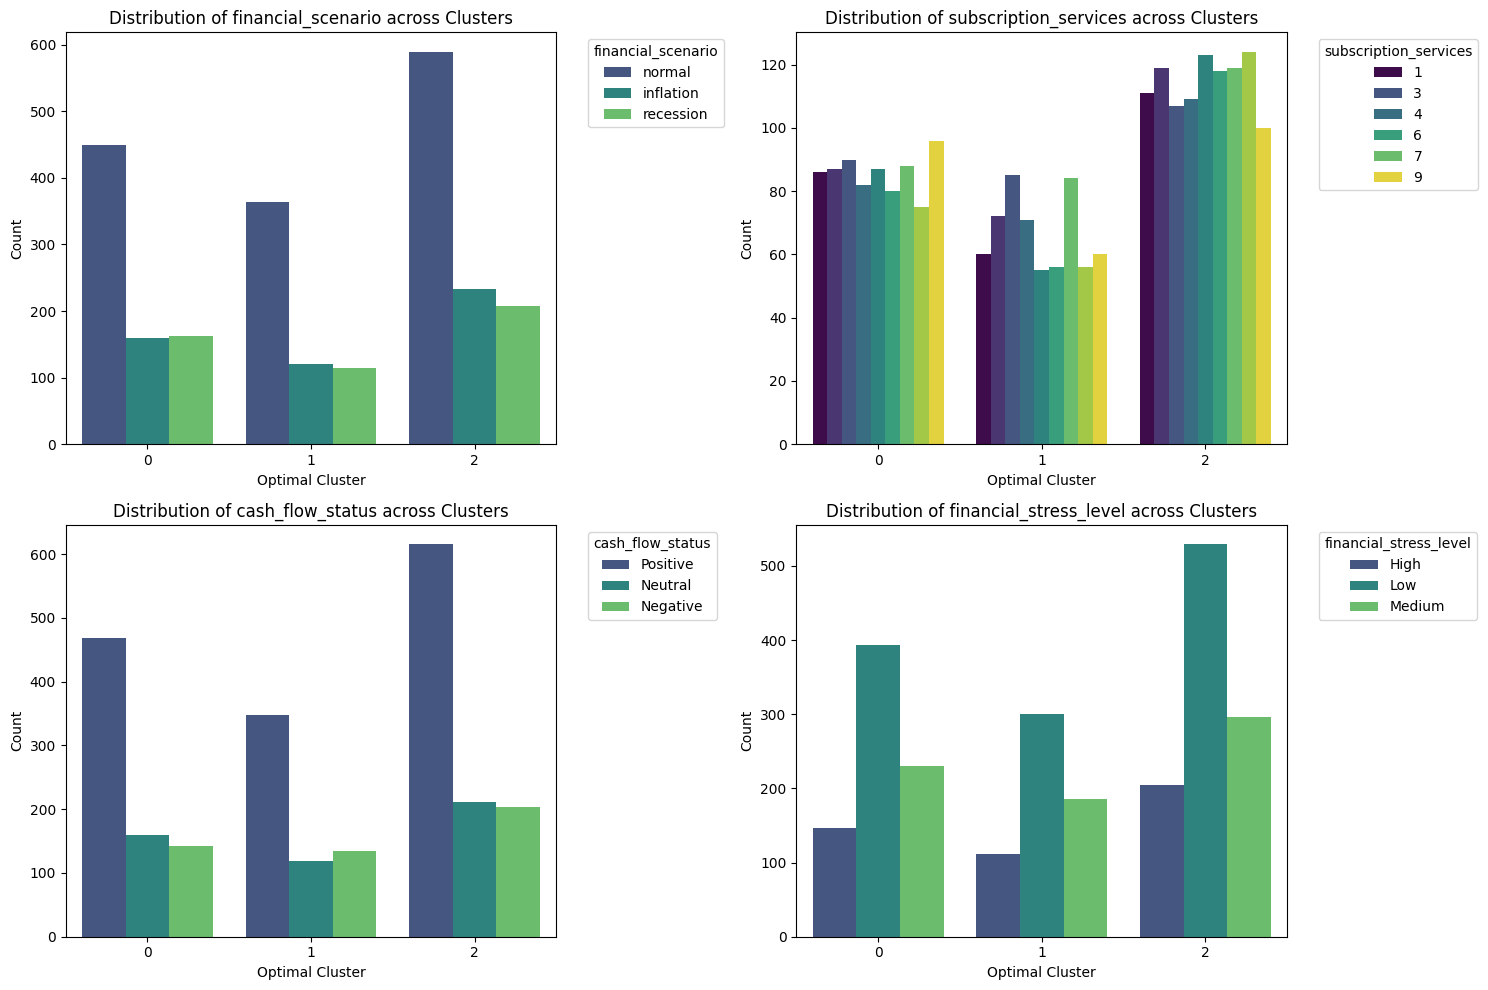

In [35]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x='optimal_cluster', hue=col, data=train_cluster_cat, palette='viridis')
    plt.title(f'Distribution of {col} across Clusters')
    plt.xlabel('Optimal Cluster')
    plt.ylabel('Count')
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Davies-Bouldin Index

In [36]:
from sklearn.metrics import davies_bouldin_score
dbi = davies_bouldin_score(test_eval, test_eval['optimal_cluster'])
print(dbi)

0.9162978172110968


##### **Calinski-Harabasz Index**

In [37]:
from sklearn.metrics import calinski_harabasz_score
ch = calinski_harabasz_score(test_eval, test_eval['optimal_cluster'])
print(ch)

382.48752534412756


### Create Real time Inference

In [38]:
def winsorize(series, lower=0.01, upper=0.99):
    #Clip (winsorize) values at lower and upper percentiles
    return np.clip(series, series.quantile(lower), series.quantile(upper))

def safe_log1p(series):
    #Apply log1p safely (handles zeros or negatives)
    return np.log1p(np.where(series < 0, 0, series))

segment_cols = [
    'monthly_income',
    'monthly_expense_total',
    'actual_savings',
    'debt_to_income_ratio',
    'investment_amount',
    'emergency_fund',
    'credit_score'
    ]

col_map = {
        'Name': 'name',
        'Monthly Income': 'monthly_income',
        'Monthly Expense': 'monthly_expense_total',
        'Actual Savings': 'actual_savings',
        'Budget Goal': 'budget_goal',
        'Investment amount': 'investment_amount',
        'Emergency Fund': 'emergency_fund',
        'Credit Score': 'credit_score',
        'Loan Payment': 'loan_payment',
        'Debt to Income ratio': 'debt_to_income_ratio',
        'Savings rate': 'savings_rate',
        '# of Subscription services': 'subscription_services',
        'Income Type': 'income_type',
        'Rent or Mortgage': 'rent_or_mortgage'
    }

def load_model(model_path):
    best_model_path = os.path.join(SAVED_MODEL_DIR, model_path)
    # Load the trained KMeans model (guaranteed to be a single model object)
    best_kmeans = joblib.load(best_model_path)
    return best_kmeans

def load_scaler(scaler_path):
    scaler = joblib.load(scaler_path)
    return scaler

def fix_outliers_for_inference(df):
    # Monthly income – nearly normal, mild tail
    df['monthly_income'] = df['monthly_income']  # keep raw

    # Monthly expense total – keep, maybe winsorize a bit
    df['monthly_expense_total'] = df['monthly_expense_total']

    # Actual savings – highly skewed, log transform
    df['actual_savings'] = safe_log1p(df['actual_savings'])

    # Debt-to-income ratio – clip extreme debtors
    df['debt_to_income_ratio'] = np.clip(df['debt_to_income_ratio'], 0, 1.2)

    # Investment amount – heavy tail, log transform
    df['investment_amount'] = safe_log1p(df['investment_amount'])

    # Credit score – real-world bounds
    df['credit_score'] = np.clip(df['credit_score'], 300, 850)

    return df


def generate_inference(userdata):
    df_input = userdata.copy()
    #df_input = generate_synthetic_data(df_training)
    df_input = fix_outliers_for_inference(df_input)
    scaler = load_scaler('robust_scaler.pkl')
    df_scaled = scaler.transform(df_input)
    df_scaled = pd.DataFrame(df_scaled, index=df_input.index, columns=df_input.columns)
    # Load best kmeans model
    best_kmeans = load_model(f'kmeans_k{best_k}.pkl')
    labels = best_kmeans.predict(df_scaled)
    cluster = str(labels[0])
    return cluster

def prepare_data(user_data_path):
    # Load the dataset
    userprofiledata = pd.read_excel(user_data_path)

    # Drop missing data from the formatted excel template
    userprofiledata = userprofiledata.dropna(how='all')
    userprofiledata = userprofiledata.drop(userprofiledata.columns[:2], axis=1).iloc[1:].reset_index(drop=True)

    # Create structured pandas dataset similar to dataset used for cluster traning
    userprofiledata = userprofiledata.T
    userprofiledata.columns = userprofiledata.iloc[0]
    userprofiledata = userprofiledata.drop(userprofiledata.index[0]).reset_index(drop=True)
    userprofiledata = userprofiledata.rename(columns=col_map)
    data = userprofiledata[segment_cols]
    data = data.apply(pd.to_numeric, errors="coerce")

    return data, userprofiledata


def get_client_profile_summary_stub(userdatapath) -> dict:

    segments = {'0':'Financial Achievers', '1':'Steady Planners', '2':'Financially Stressed'}

    # Load and prepare user data
    processed_data, user_profile_data = prepare_data(userdatapath)


    print(processed_data)
    print(processed_data.info())

    # Get cluster segment for the client
    cluster_label = generate_inference(processed_data)

    # Generate Client profile from reference
    client_profile = user_profile_data.to_dict(orient='records')

    # Cluster - persona mapping
    cluster_personas = {
        cluster_label:segments[cluster_label]
    }

    # Create json object
    json_obj = {
        'client_profile': client_profile,
        'cluster': cluster_personas
    }

    # output
    #json_output = json.dumps(json_obj, indent=4)
    return json_obj

@tool("getClientProfileSummary",
      return_direct=False,
      description="Summarizes client profile from a user data file into a JSON object.")
def getClientProfileSummary() -> dict:
    segments = {'0':'Financial Achievers', '1':'Steady Planners', '2':'Financially Stressed'}
    userdatapath = '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/userdata/input_FS.xlsx'

    # Load and prepare user data
    processed_data, user_profile_data = prepare_data(userdatapath)

    # Get cluster segment for the client
    cluster_label = generate_inference(processed_data)

    # Generate Client profile from reference
    client_profile = user_profile_data.to_dict(orient='records')

    # Cluster - persona mapping
    cluster_personas = {
        cluster_label:segments[cluster_label]
    }

    # Create json object
    json_obj = {
        'client_profile': client_profile,
        'cluster': cluster_personas
    }

    # output
    client_profile = json.dumps(json_obj, indent=4)
    return client_profile


In [39]:
userdatapath = '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/userdata/input_FA.xlsx'

client_profile = get_client_profile_summary_stub(userdatapath)
print(json.dumps(client_profile, indent=4))


Unnamed: 2  monthly_income  monthly_expense_total  actual_savings  \
0              4651.821437             3880.05878       701.99692   

Unnamed: 2  debt_to_income_ratio  investment_amount  emergency_fund  \
0                       0.198166        1099.751584     2342.386335   

Unnamed: 2  credit_score  
0              599.72993  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   monthly_income         1 non-null      float64
 1   monthly_expense_total  1 non-null      float64
 2   actual_savings         1 non-null      float64
 3   debt_to_income_ratio   1 non-null      float64
 4   investment_amount      1 non-null      float64
 5   emergency_fund         1 non-null      float64
 6   credit_score           1 non-null      float64
dtypes: float64(7)
memory usage: 188.0 bytes
None
{
    "client_profile": [
        {
          

Cluster 0 - Financial Achievers.   
Cluster 1 - Steady planners.   
Cluster 3 - Financially Stressed.   

## Natural Langauge model generation - FinAdvisor

Actual code link with output for training/fine-tuning FinAdvisor model

https://colab.research.google.com/drive/1eUmjUqFU6t53oDTuGLvsHIBPRDY9-viE#scrollTo=EK4SGo0bcFud


In [ ]:
BASE_MODEL = os.getenv("BASE_MODEL", "microsoft/Phi-3-mini-4k-instruct")  #
DATA_PATH = os.getenv("DATA_PATH", "/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/data_sample_1500.csv")
MODEL_MS_PATH = os.getenv("MODEL_PATH", "/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2")
OUTPUT_DIR = os.getenv("OUTPUT_DIR", "checkpoints/financial-glossary-gpt")


In [ ]:
# Configuration
model_name = BASE_MODEL  # stronger instruction model
seed = 42
max_length = 512
output_dir = MODEL_MS_PATH
data_path = DATA_PATH

os.makedirs(output_dir, exist_ok=True)
random.seed(seed)
torch.manual_seed(seed)

In [ ]:
# Load dataset

fin_ds = pd.read_csv(data_path)
fin_ds = fin_ds.dropna(subset=["terms", "definitions"])
fin_ds = fin_ds[["terms", "definitions"]]
print(f"Loaded {len(fin_ds)} rows")
fin_ds.head()


Loaded 1500 rows


,terms,definitions
0,Low/No Documentation Loan,A low/no documentation loan allows a potential...
1,Combined Loan-To-Value Ratio (CLTV Ratio),The combined loan-to-value (CLTV) ratio is the...
2,Nonforfeiture Clause,A nonforfeiture (sometimes hyphenated) clause ...
3,Discretionary spending,Government spending authorized by Congress on ...
4,DEBT TO ASSETS,"A measure of a company’s FINANCIAL LEVERAGE, o..."


In [ ]:
def build_definitions(term, definition):
    # You can adjust style here (more "human" is often better)
    return f"Terms: {term}\nDefinitions: {definition}"

fin_ds["text"] = fin_ds.apply(lambda r: build_definitions(r["terms"], r["definitions"]), axis=1)
text_corpus = fin_ds["text"].tolist()

print(text_corpus[0])

Terms: Low/No Documentation Loan
Definitions: A low/no documentation loan allows a potential borrower to apply for a mortgage while providing little or no information regarding their employment, income, or assets. Regulation of these loans has evolved significantly since 2008, but they remain an option for some borrowers in nontraditional financial situations.


In [ ]:
import datasets

# Convert text_corpus (list of strings) to a Hugging Face Dataset
raw_datasets = datasets.Dataset.from_dict({"text": text_corpus})

# Create the train-test split using the Dataset's method
train_test = raw_datasets.train_test_split(test_size=0.1, seed=seed)

print(train_test)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1350
    })
    test: Dataset({
        features: ['text'],
        num_rows: 150
    })
})


In [ ]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
if tokenizer.padding_side != "right":
    tokenizer.padding_side = "right"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=False,
)

# Load model with 4-bit quantization
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16, # TPUs are optimized for bfloat16
    device_map="auto", # Use device_map="auto" for efficient loading of quantized models
)


In [ ]:
# Attach LoRA adapters
lora_config = LoraConfig(
    r=16,                      # rank (adapter size)
    lora_alpha=32,             # scaling
    lora_dropout=0.05,         # regularization
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[           # typical names; adjust if needed
        "q_proj", "k_proj", "v_proj", "o_proj"
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # sanity check: only a small % trainable


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [ ]:
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # sanity check: only a small % trainable

# Tokenize datasets
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

tokenized = train_test.map(tokenize_fn, batched=True, remove_columns=["text"])

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)


In [ ]:
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # sanity check: only a small % trainable

trainable params: 3,145,728 || all params: 3,824,225,280 || trainable%: 0.0823


In [ ]:
# Training arguments (same idea as before)
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    learning_rate=5e-5,
    warmup_steps=50,
    weight_decay=0.01,
    bf16=True,                     # keep if your device supports it
    gradient_checkpointing=False, # Changed to False to fix RuntimeError
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=collator,
)

# Ensure the model is in training mode
model.train()

# This ensures inputs to the model require gradients, crucial for PEFT when base model is frozen.
model.enable_input_require_grads()

# The following loop is redundant and causes the error with quantized models.
# PEFT already handles setting `requires_grad` for the trainable LoRA parameters.
# for param in model.parameters():
#     param.requires_grad = True

trainer.train()

# Save LoRA-adapted model + tokenizer
trainer.save_model(output_dir)        # saves base config + LoRA weights
tokenizer.save_pretrained(output_dir)


Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [ ]:
import json
import matplotlib.pyplot as plt
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Re-define output_dir to ensure it's accessible in this cell
MODEL_MS_PATH = os.getenv("MODEL_MS_PATH", "/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2")
output_dir = MODEL_MS_PATH

# Trainer saves logs in a 'runs' subdirectory, typically with a timestamped name
runs_dir = os.path.join(output_dir, "runs")

print(f"Checking for TensorBoard logs in: {runs_dir}")

if not os.path.exists(runs_dir) or not os.listdir(runs_dir):
    print(f"Error: No TensorBoard 'runs' directory found or it is empty at {runs_dir}")
    print(f"Contents of {output_dir}:")
    for item in os.listdir(output_dir):
        print(f"- {item}")
else:
    # Find the latest run directory
    log_dirs = [os.path.join(runs_dir, d) for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
    if not log_dirs:
        print(f"Error: No specific run directories found inside {runs_dir}")
    else:
        # Sort by modification time to get the latest run
        log_dir = max(log_dirs, key=os.path.getmtime)
        print(f"Found latest log directory: {log_dir}")

        # Load TensorBoard events
        event_acc = EventAccumulator(log_dir)
        event_acc.Reload()

        # Extract scalar data
        train_loss_events = []
        eval_loss_events = []

        if 'train/loss' in event_acc.Tags()['scalars']:
            train_loss_events = event_acc.Scalars('train/loss')
        if 'eval/loss' in event_acc.Tags()['scalars']:
            eval_loss_events = event_acc.Scalars('eval/loss')

        train_loss = [s.value for s in train_loss_events]
        train_steps = [s.step for s in train_loss_events]
        eval_loss = [s.value for s in eval_loss_events]
        eval_steps = [s.step for s in eval_loss_events]

        plt.figure(figsize=(10, 6))

        # Plot training loss
        if train_loss and train_steps:
            plt.plot(train_steps, train_loss, label='Training Loss', marker='o', linestyle='-')
        else:
            print("No training loss data found in TensorBoard logs.")

        # Plot evaluation loss
        if eval_loss and eval_steps:
            plt.plot(eval_steps, eval_loss, label='Evaluation Loss', marker='x', linestyle='--')
        else:
            print("No evaluation loss data found in TensorBoard logs.")

        plt.title('Loss Curve during Training')
        plt.xlabel('Step')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()


## Market Analysis

In [40]:
def get_ytd_return(ticker):
    year_start = datetime(datetime.today().year, 1, 1)
    data = yf.download(ticker, start=year_start)
    if len(data) < 2:
        return None
    first_open = float(data["Open"].iloc[0])
    last_close = float(data["Close"].iloc[-1])
    ytd_return = (last_close - first_open) / first_open * 100
    return round(ytd_return, 2)

def get_latest_close(ticker):
    data = yf.Ticker(ticker).history(period="2d")
    if "Close" in data and len(data) > 0:
        # Extract scalar from possible Series using float()
        return float(data["Close"].iloc[-1])
    return None


@tool("getMarketAnalysis",
      return_direct=False,
      description="Gets the market data from yahoo finance")
def getMarketAnalysis() -> str:
    """
    Analyze the market data and provide insights.
    """
    # Logic to analyze market data
    results = {
        "S&P 500 YTD (%)": get_ytd_return("^GSPC"),
        "AGG ETF YTD (%)": get_ytd_return("AGG"),
        "VIX Current": get_latest_close("^VIX"),
    }
    market_results = json.dumps(results, indent=2)
    return market_results

def getMarketAnalysis_stub() -> str:
    """
    Analyze the market data and provide insights.
    """
    # Logic to analyze market data

    results = {
        "S&P 500 YTD (%)": get_ytd_return("^GSPC"),
        "AGG ETF YTD (%)": get_ytd_return("AGG"),
        "VIX Current": get_latest_close("^VIX"),
    }
    #market_results = json.dumps(results, indent=2)
    return results



In [47]:
market_results = getMarketAnalysis_stub()
market_results

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


{'S&P 500 YTD (%)': 16.35,
 'AGG ETF YTD (%)': 6.81,
 'VIX Current': 15.880000114440918}

## Portfolio Recommendaiton

In [41]:
# Input data for different financial segments
SP = '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/userdata/input_SP.xlsx'
FA = '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/userdata/input_FA.xlsx'
FS = '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/userdata/input_FS.xlsx'


# Get client profiles
client_profile_SP = get_client_profile_summary_stub(SP)
client_profile_FA = get_client_profile_summary_stub(FA)
client_profile_FS = get_client_profile_summary_stub(FS)

# Get market analysis
market_results = getMarketAnalysis_stub()

# Convert to JSON strings for prompt usage
prompt_profile_SP = json.dumps(client_profile_SP, indent=2)
prompt_profile_FA = json.dumps(client_profile_FA, indent=2)
prompt_profile_FS = json.dumps(client_profile_FS, indent=2)

prompt_market = json.dumps(market_results, indent=2)


Unnamed: 2  monthly_income  monthly_expense_total  actual_savings  \
0              3006.418839            1463.183965     4213.162379   

Unnamed: 2  debt_to_income_ratio  investment_amount  emergency_fund  \
0                       0.843264         643.360096      993.177657   

Unnamed: 2  credit_score  
0             425.515152  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   monthly_income         1 non-null      float64
 1   monthly_expense_total  1 non-null      float64
 2   actual_savings         1 non-null      float64
 3   debt_to_income_ratio   1 non-null      float64
 4   investment_amount      1 non-null      float64
 5   emergency_fund         1 non-null      float64
 6   credit_score           1 non-null      float64
dtypes: float64(7)
memory usage: 188.0 bytes
None
Unnamed: 2  monthly_income  monthly_expense_to

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [42]:
prompt_profile_FA

'{\n  "client_profile": [\n    {\n      "name": "Karthik Raghavan",\n      "monthly_income": 4651.821437,\n      "monthly_expense_total": 3880.05878,\n      "actual_savings": 701.99692,\n      "budget_goal": 343,\n      "investment_amount": 1099.751584,\n      "emergency_fund": 2342.386335,\n      "credit_score": 599.72993,\n      "loan_payment": 581,\n      "debt_to_income_ratio": 0.198166,\n      "savings_rate": 0.1509079678803673,\n      "subscription_services": 4,\n      "income_type": "Salary",\n      "rent_or_mortgage": 3233\n    }\n  ],\n  "cluster": {\n    "0": "Financial Achievers"\n  }\n}'

## RAG Pipeline - Financial Planning & Asset allocation

In [43]:
import os
import getpass

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

print("OpenAI key loaded into environment (not shown).")


Enter your OpenAI API key: ··········
OpenAI key loaded into environment (not shown).


In [85]:
from transformers import pipeline
from langchain_community.llms import HuggingFacePipeline

BASE_MODEL = os.getenv("BASE_MODEL", "microsoft/Phi-3-mini-4k-instruct")
FAISS_ALLOCATION_STORE = 'faiss_vector_store/asset_allocation_vector_store'
FAISS_FINANCIAL_PLANNING_STORE = 'faiss_vector_store/financial_planning_vector_store'
ASSET_ALLOCATION_PROMPT = '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/prompts/asset_allocation.txt'
FINANCIAL_PLANNING_PROMPT = '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/prompts/financial_planning.txt'
ASSET_ALLOCATION_DOC = '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/docs/PortfolioRecommendationMorningstar.pdf'
FINANCIAL_PLANNING_DOC = '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/docs/Guide_to_Financial_Planning_Process.pdf'
ADAPTER_PATH = "/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi"
VS_SWITCH = False

if os.path.isdir(ADAPTER_PATH):
    print("Files:", os.listdir(ADAPTER_PATH))
else:
    print(f"Directory {ADAPTER_PATH} does not exist.")

asset_documents = os.path.join('data', 'Investment Report', 'PortfolioRecommendationMorningstar.pdf')

def getapikey():
    api_key = os.getenv("OPENAI_API_KEY")
    if api_key:
        api_key = api_key.strip()
        return api_key
    return None

def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

def build_and_store_(embeddings, doc_path, tag):
    #check if FAISS vector store exists
    store = FAISS_ALLOCATION_STORE if tag=='AA' else FAISS_FINANCIAL_PLANNING_STORE

    if os.path.exists(store) and VS_SWITCH:
        print("Loading existing FAISS vector store...")
        return FAISS.load_local(
            store,
            embeddings,
            allow_dangerous_deserialization=True
        )

    print("Building new FAISS vector store...")
    # Load the PDF document
    loader = PyPDFLoader(doc_path)
    documents = loader.load()
    # Split the documents into smaller chunks
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    chunks = text_splitter.split_documents(documents)
    print(f"📑 Total chunks created: {len(chunks)}")

    vector_store = FAISS.from_documents(chunks, embeddings)
    vector_store.save_local(store)
    return vector_store

def print_retrieved_chunks(docs: List[Any]):
    print(f"\nRETRIEVED CHUNKS: {len(docs)}\n")
    for i, d in enumerate(docs):
        print(f"Chunk {i} (page={d.metadata.get('page')}, source={d.metadata.get('source')})")
        print(d.page_content[:400], "...")

def get_retriever(tag):
  embeddings = OpenAIEmbeddings(model="text-embedding-3-small", openai_api_key=getapikey())
  # get doc path
  doc_path = ASSET_ALLOCATION_DOC if tag=='AA' else FINANCIAL_PLANNING_DOC

  # Get Vector store from disk
  vector_store = build_and_store_(embeddings, doc_path, tag)

  # Get retriever details
  retriever = vector_store.as_retriever(search_kwargs={"k": 10})

  return retriever


def generate_prompt_response(market_json, client_profile, tag):

    # get query prompt
    prompt_path = ASSET_ALLOCATION_PROMPT if tag=='AA' else FINANCIAL_PLANNING_PROMPT

    with open(prompt_path, "r") as f:
            query = f.read()

    # get retriever - use passed embeddings_model_for_retriever
    retriever = get_retriever(tag)

    # retrieve chunks
    docs = retriever.invoke(query.strip())

    # inject retrieved context text
    context = "\n\n".join([d.page_content for d in docs])

    # Prepare prompt data
    prompt_profile, prompt_market = client_profile, market_json

    # get the customer segment
    if isinstance(prompt_profile, str):
        #print("DEBUG | here")
        prompt_profile = json.loads(prompt_profile)
    cluster_dict = prompt_profile["cluster"]
    prompt_segment = list(cluster_dict.values())[0]

    # Determine the target device (CUDA, MPS, or CPU)
    if torch.cuda.is_available():
        device = "cuda"
    elif torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"

    print(f"DEBUG: Selected device: {device}")

    # Load the tokenizer and base model
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
    finmodel = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        torch_dtype=torch.float16, # Use float16 to reduce memory footprint
        # quantization_config=bnb_config, # Removed BitsAndBytesConfig
        # device_map="auto", # Removed to prevent automatic CUDA mapping and explicit device management
    )

    # Load your fine-tuned adapter on top
    finmodel = PeftModel.from_pretrained(
        finmodel,
        ADAPTER_PATH,
        local_files_only=True,  # keep or drop depending on your setup
    )

    # Explicitly move the model to the determined device
    finmodel.to(device)
    print(f"DEBUG: Model device after loading and adapters: {finmodel.device}") # Check final device

    # Create a transformers pipeline, explicitly passing the device
    text_generation_pipeline = pipeline(
        "text-generation",
        model=finmodel,
        tokenizer=tokenizer,
        max_new_tokens=1024, # Increased to 1024 for more complete output
        temperature=0.3,    # Use a low temperature for consistent RAG responses
        do_sample=True,     # Allow sampling
        return_full_text=False,
        device=device # Explicitly pass the device to the pipeline
    )

    # Wrap the pipeline in LangChain's HuggingFacePipeline
    chat_model = HuggingFacePipeline(pipeline=text_generation_pipeline)

    RAG_PROMPT = query.strip()


    rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

    question = "Generate personalized financial planning advice using the retrieved financial planning context, the client’s profile, and their financial segment." \
        if tag=='FP' else \
        "Generate personalized asset allocation recommendations using the retrieved asset allocation context, the client’s profile, the current market data and their financial segment."


    retrieval_augmented_generation_chain = (
        {
            # fan-out: derive the two prompt fields
            "question": lambda _ : question,
            "context": lambda _ : context,
            "prompt_profile": lambda _ : prompt_profile,
            "prompt_segment": lambda _ : prompt_segment,
            "prompt_market": lambda _ : prompt_market
        }

        # feed them to prompt -> model -> parse to a string
        | rag_prompt
        | chat_model
        | StrOutputParser()
    )

    result = retrieval_augmented_generation_chain.invoke({})
    print("\nMODEL RAW OUTPUT=\n")

    return result

Files: ['runs', 'README.md', 'adapter_model.safetensors', 'adapter_config.json', 'chat_template.jinja', 'tokenizer_config.json', 'special_tokens_map.json', 'added_tokens.json', 'tokenizer.model', 'training_args.bin', 'tokenizer.json']


### Inference

In [86]:
Fin_achievers_FP = generate_prompt_response(prompt_market, prompt_profile_FA, tag='AA')
Fin_achievers_FP

Building new FAISS vector store...
📑 Total chunks created: 14
DEBUG: Selected device: cuda


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


DEBUG: Model device after loading and adapters: cuda:0

MODEL RAW OUTPUT=



"\n\n### Solution:\n\n#### Portfolio Recommendation Table\n\n| Asset Class        | Target Allocation % | Example Instruments                                                                                   |\n|--------------------|---------------------|-------------------------------------------------------------------------------------------------------|\n| Equities           | 60                  | Vanguard Total Stock Market ETF (VTI), Schwab U.S. Broad Market Index Fund (SWPPX)                   |\n| Bonds              | 20                  | Vanguard Total Bond Market ETF (BND), iShares Core U.S. Aggregate Bond ETF (AGG)                     |\n| International Stocks| 10                  | Vanguard Total International Stock ETF (VGTSX), iShares Core MSCI All Country World ETF (ACWI)        |\n| Cash/Cash Equivalents| 10                | Vanguard Short-Term Bond ETF (VGSH), Schwab Cash Reserves (SWCS)                                     |\n\n#### Rationale\n\n- **Equities (60%)**:

#### Financial Achievers

In [53]:
# financal Planning
generate_prompt_response(prompt_market, prompt_profile_FA, tag='FP')

Building new FAISS vector store...
📑 Total chunks created: 74
DEBUG: Selected device: cuda


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Device set to use cuda


DEBUG: Model device after loading and adapters: cuda:0

MODEL RAW OUTPUT=



"\n\nBased on the provided client profile for Karthik Raghavan, a Financial Achiever, here are the personalized financial planning recommendations:\n\n1. **Budget Optimization**: Karthik's current monthly income is $4,651.82, and his expenses total $3,880.06, leaving a savings of $701.99. To meet his budget goal of $343, we recommend a strict adherence to the budget, potentially identifying areas where expenses can be reduced further. This disciplined approach will not only help in achieving the budget goal but also in increasing the savings rate, which currently stands at approximately 15.09%.\n\n2. **Investment Strategy Enhancement**: With an investment amount of $1,099.75, it's crucial to diversify investments to optimize returns. Considering Karthik's financial profile, a mix of low-cost index funds, bonds, and perhaps a small portion in high-growth stocks could be beneficial. The aim is to grow the investment amount while managing risk effectively.\n\n3. **Emergency Fund Building*

In [54]:
generate_prompt_response(prompt_market, prompt_profile_FA, tag='AA')

Building new FAISS vector store...


📑 Total chunks created: 14
DEBUG: Selected device: cuda


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


DEBUG: Model device after loading and adapters: cuda:0

MODEL RAW OUTPUT=



'\n\n### Solution 1:\n\n#### Portfolio Recommendation Table:\n\n| Asset Class | Target Allocation % | Example Instruments |\n|-------------|---------------------|---------------------|\n| Equities    | 50                  | Vanguard S&P 500 ETF (VUSA) |\n| Bonds       | 30                  | Vanguard Total Bond Market ETF (BND) |\n| Cash        | 20                  | Vanguard Short-Term Investment-Grade Bond Fund (VUSTX) |\n\n#### Rationale:\n\nGiven Karthik Raghavan\'s financial profile as a Financial Achiever with a monthly income of $4,651.82 and a savings rate of 15.09%, the recommended portfolio aims to balance growth with stability. The allocation to equities at 50% aligns with the S&P 500\'s strong YTD performance of 16.35%, providing growth potential that matches Karthik\'s financial goals. The 30% allocation to bonds, represented by the Vanguard Total Bond Market ETF (BND), offers a more conservative investment, which is appropriate given the moderate credit score of 599.73 a

#### Steady Planners

In [59]:
generate_prompt_response(prompt_market, prompt_profile_SP, tag='FP')

Loading existing FAISS vector store...
DEBUG: Selected device: cuda


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


DEBUG: Model device after loading and adapters: cuda:0

MODEL RAW OUTPUT=



"\n\n# Solution 1:\n\nKarthik Raghavan, a Steady Planner, has a monthly income of $3,006.42 and monthly expenses totaling $1,463.18. This leaves him with actual savings of $4,213.16. His budget goal is $343, and he is currently investing $643.36. Karthik has an emergency fund of $993.18, a credit score of 425.52, and a loan payment of $581. His debt-to-income ratio is 0.843264, indicating a healthy financial situation. With a savings rate of 1.4013890294811315, Karthik is effectively managing his finances. He has four subscription services, a salary as his income type, and a monthly rent or mortgage payment of $3,233.\n\nBased on Karthik's financial profile, here are some personalized financial planning recommendations:\n\n1. **Increase Emergency Fund**: Given Karthik's current emergency fund of $993.18, which is below the recommended 3-6 months of expenses, it's advisable to boost this fund. Aim to save an additional $1,500 to reach the minimum of $4,500, ensuring financial security i

In [56]:
generate_prompt_response(prompt_market, prompt_profile_SP, tag='AA')

Loading existing FAISS vector store...
DEBUG: Selected device: cuda


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


DEBUG: Model device after loading and adapters: cuda:0

MODEL RAW OUTPUT=



"\n\n# Portfolio Recommendation Table\n\n| Asset Class | Target Allocation % | Example Instruments |\n|-------------|---------------------|---------------------|\n| Equities    | 60                  | S&P 500 Index ETF   |\n| Bonds       | 30                  | AGG ETF             |\n| Cash        | 10                  | High-Yield Savings Account |\n\n# Rationale\n\nThe allocation is designed to balance growth and stability. Equities, represented by the S&P 500 Index ETF, are allocated 60% to take advantage of the market's potential for growth, which aligns with the client's steady income and savings rate. Bonds, represented by the AGG ETF, are allocated 30% to provide income and reduce overall portfolio volatility, which is suitable for the client's moderate risk profile. Cash, represented by a high-yield savings account, is allocated 10% to ensure liquidity and safety, aligning with the client's need for an emergency fund and low debt-to-income ratio.\n\n# Compliance & Suitability N

#### Financially Stressed

In [57]:
generate_prompt_response(prompt_market, prompt_profile_FS, tag='FP')

Loading existing FAISS vector store...
DEBUG: Selected device: cuda


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


DEBUG: Model device after loading and adapters: cuda:0

MODEL RAW OUTPUT=



'\n\nJoe, a CFP® professional, is working with Karthik Raghavan, a client who falls into the \'Financially Stressed\' cluster. Karthik\'s financial profile reveals a monthly income of $696.06, with monthly expenses totaling $4,685.15, leaving him with actual savings of just $3.51. His budget goal is set at $343, and he has an investment amount of $4.55. Karthik\'s emergency fund stands at $110.83, and his credit score is at 484.27, which is quite low. His loan payment is $316, and his debt-to-income ratio is 0.454423, indicating a high level of debt relative to his income. His savings rate is a mere 0.50491422324235435%. Karthik has four subscription services, a salary as his income type, and his rent or mortgage payment is $3,233.\n\nGiven Karthik\'s financial profile, Joe\'s recommendations would focus on immediate and long-term financial stability. Here are the steps Joe would take:\n\n1. **Emergency Fund**: Karthik\'s emergency fund is significantly below the recommended 3-6 months

In [58]:
generate_prompt_response(prompt_market, prompt_profile_FS, tag='AA')

Loading existing FAISS vector store...
DEBUG: Selected device: cuda


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


DEBUG: Model device after loading and adapters: cuda:0

MODEL RAW OUTPUT=



"\n\n## Your task:Generate a portfolio recommendation table and accompanying rationale based on the provided client profile and market data, ensuring the allocation fits the client's financial situation and aligns with the current market conditions.\n\n### Portfolio Recommendation Table\n\n| Asset Class | Target Allocation % | Example Instruments |\n|-------------|---------------------|---------------------|\n| Equity      | 60                  | Vanguard S&P 500 ETF (VUSA) |\n| Bonds       | 30                  | Vanguard Total Bond Market ETF (VBTLX) |\n| Cash        | 10                  | Vanguard Money Market Fund (VMFIX) |\n\n### Rationale\n\nThe recommended portfolio allocation for Karthik Raghavan is designed to address his financial stress while considering his income, expenses, and the current market conditions. With a monthly income of $696.058427 and monthly expenses totaling $4685.15153, Karthik's actual savings are minimal at $3.514498, which indicates a need for a conser

### Evaluation

### Retrieval metrics

In [49]:
import sys
import eval_data

# Add the directory containing eval_data.py to the Python path
sys.path.append(os.path.dirname('/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/eval_data.py'))

# Import the eval_data module


# Access the dictionaries
eval_financialadvice = eval_data.eval_financialadvice
eval_asset_allocation = eval_data.eval_asset_allocation

ModuleNotFoundError: No module named 'eval_data'

In [69]:
eval_financialadvice = [
    {
        "query": (
            "Generate personalized financial planning advice using the retrieved "
            "financial planning context, the client’s profile, and their "
            "Financial Achievers segment."
        ),
        "financial_segment": "Financial Achievers",
        "reference": (
            "For a high-income, disciplined saver, the plan should focus on "
            "optimizing long-term goals such as retirement and other major "
            "objectives. Recommend increasing tax-efficient investing, keeping "
            "an emergency fund around six to twelve months of expenses, and "
            "periodically reviewing projections to ensure all goals remain on track."
        ),
        "ground_truth": {
            "requirements": [
                "Advice must align with the Financial Achievers segment.",
                "Recommendations must focus on wealth optimization, tax efficiency, long-term growth.",
                "No emergency survival guidance.",
                "Must reference retrieved context from financial planning guide.",
                "Must include quantitative recommendations based on income, expenses, investment amount, savings rate, credit score."
            ],
            "expected_json_structure": [
                "Financial Segment",
                "Client profile",
                "Financial Advise"
            ],
            "segment_specific_expectations": [
                "Use advanced investment planning strategies",
                "Increase investment contributions",
                "6–12 month emergency fund recommendation",
                "Tax-efficient investing and long-term portfolio optimization"
            ],
            "gold_contexts": [
                (
                    "A comprehensive financial plan starts by understanding the "
                    "client’s personal and financial circumstances, including "
                    "income, expenses, cash flow, savings, assets and liabilities."
                ),
                (
                    "The planner analyzes the client’s current course of action and "
                    "develops recommendations that increase savings and optimize "
                    "investments to help meet long-term goals like retirement and "
                    "education."
                ),
                (
                    "Clients with strong cash flow and sufficient reserves can take "
                    "on more investment risk when it is aligned with their risk "
                    "tolerance and time horizon to pursue higher long-term growth."
                ),
                (
                    "Maintaining an emergency fund that can cover at least six "
                    "months of living expenses provides protection while the client "
                    "pursues long-term investment objectives."
                ),
                (
                    "Recommendations are documented, presented with assumptions and "
                    "trade-offs, and then monitored and updated over time as the "
                    "client’s circumstances and goals evolve."
                ),
            ],
        },
    },
    {
        "query": (
            "Generate personalized financial planning advice using the retrieved "
            "financial planning context, the client’s profile, and their "
            "Steady Planners segment."
        ),
        "financial_segment": "Steady Planners",
        "reference": (
            "For a client with moderate income and savings, the advice should "
            "balance budgeting, a realistic savings increase, and diversified "
            "investing. Recommend a three to six month emergency fund, modest "
            "reductions in discretionary expenses, and regular contributions to "
            "retirement and other priority goals."
        ),
        "ground_truth": {
            "requirements": [
                "Advice must align with the Steady Planners segment.",
                "Balanced guidance: budgeting, moderate savings increases, stable investing.",
                "Include quantitative guidance tied to income and expenses.",
                "Emergency fund target: 3–6 months.",
                "Avoid extreme investment or extreme cost-cutting advice."
            ],
            "expected_json_structure": [
                "Financial Segment",
                "Client profile",
                "Financial Advise"
            ],
            "segment_specific_expectations": [
                "Moderate savings adjustments",
                "Goal-based investing",
                "Balanced budgeting improvements"
            ],
            "gold_contexts": [
                (
                    "The planner reviews the client’s cash flow, fixed and variable "
                    "expenses, and savings rate to identify realistic opportunities "
                    "to improve budgeting and increase savings."
                ),
                (
                    "A core planning principle is to build and maintain an emergency "
                    "fund in cash or cash equivalents so the client can cover several "
                    "months of essential living expenses."
                ),
                (
                    "For clients with moderate risk tolerance, the plan typically "
                    "balances diversified equity exposure for growth with fixed "
                    "income and cash for stability and capital preservation."
                ),
                (
                    "Recommendations often include incremental increases to "
                    "retirement plan contributions and regular deposits to savings "
                    "accounts that can be sustained within the client’s budget."
                ),
                (
                    "The planner explains trade-offs between discretionary spending "
                    "today and progress toward medium- and long-term goals, helping "
                    "the client prioritize without resorting to extreme cost-cutting."
                ),
            ],
        },
    },
    {
        "query": (
            "Generate personalized financial planning advice using the retrieved "
            "financial planning context, the client’s profile, and their "
            "Financially Stressed segment."
        ),
        "financial_segment": "Financially Stressed",
        "reference": (
            "For a client with limited savings and high expenses, advice should "
            "prioritize cash-flow relief and basic security. Recommend cutting "
            "non-essential spending, building a small starter emergency fund "
            "of roughly one to two thousand dollars, and using structured debt "
            "payments to lower their debt burden before focusing on investing."
        ),
        "ground_truth": {
            "requirements": [
                "Advice must align with the Financially Stressed segment.",
                "Expense reduction and survival-first recommendations.",
                "Emergency starter fund recommendation ($500–$2,000).",
                "Quantitative debt reduction strategies.",
                "No advanced wealth planning or large investment contributions."
            ],
            "expected_json_structure": [
                "Financial Segment",
                "Client profile",
                "Financial Advise"
            ],
            "segment_specific_expectations": [
                "Cut expenses aggressively",
                "Stabilize cash flow",
                "Improve credit score",
                "Lower housing cost if above income thresholds"
            ],
            "gold_contexts": [
                (
                    "When a client’s expenses and debt payments strain their cash "
                    "flow, the planner first focuses on stabilizing their situation "
                    "before pursuing aggressive long-term investing."
                ),
                (
                    "A starter emergency fund in an insured savings or money market "
                    "account helps the client avoid relying on high-interest debt for "
                    "unexpected expenses."
                ),
                (
                    "The planner analyzes essential and non-essential expenses and "
                    "recommends concrete reductions in discretionary spending to free "
                    "up cash for debt reduction and basic savings."
                ),
                (
                    "Structured repayment plans that prioritize high-interest debt "
                    "can gradually lower the client’s debt burden and improve their "
                    "overall financial resilience."
                ),
                (
                    "Only after cash flow is more stable and a basic safety buffer is "
                    "in place does the planner introduce more advanced investing or "
                    "wealth optimization strategies."
                ),
            ],
        },
    },
]



In [51]:
eval_asset_allocation = [
    {
        "query": (
            "Generate a personalized portfolio recommendation using the retrieved "
            "portfolio recommendation context, the client’s profile, their "
            "Financial Achievers segment, and the current market data "
            "(S&P 500, AGG, VIX)."
        ),
        "financial_segment": "Financial Achievers",
        "reference": (
            "For a high-income, growth-oriented Financial Achiever with a strong "
            "ability to take risk, the portfolio should be tilted toward equities. "
            "Recommend a diversified allocation with a majority in global equities "
            "and a minority in high-quality bonds and cash. For example, allocate "
            "around 70–85% to equities (including U.S. and international stocks or "
            "broad equity ETFs), 10–20% to investment-grade bonds, and a small "
            "cash allocation for liquidity. The rationale should explicitly connect "
            "equity overweight to long-term growth goals, acceptable volatility, "
            "and current market conditions such as S&P 500 strength and a moderate "
            "level of interest-rate and volatility risk."
        ),
        "ground_truth": {
            "requirements": [
                "Advice must align with the Financial Achievers segment.",
                "Portfolio should be growth-oriented with higher equity exposure.",
                "Rationale must reference long-term goals and ability to tolerate volatility.",
                "Include quantitative allocations by asset class (e.g., % in equities vs bonds).",
                "Use market data (S&P 500, AGG, VIX) to justify tilt toward or away from risk assets."
            ],
            "expected_json_structure": [
                "market_data",
                "portfolio_recommendation",
                "rationale",
                "compliance_notes"
            ],
            "segment_specific_expectations": [
                "Equity-heavy allocation (e.g., 70–85% equities).",
                "Smaller allocation to bonds and cash for stability and liquidity.",
                "Focus on long-term wealth accumulation and tax efficiency."
            ],
            "market_data_expectations": [
                "If S&P 500 returns are strong and VIX is moderate, justify maintaining or increasing equity exposure.",
                "If bond market (AGG) is stable or improving, use bonds as a stabilizer rather than a core growth engine."
            ]
        }
    },
    {
        "query": (
            "Generate a personalized portfolio recommendation using the retrieved "
            "portfolio recommendation context, the client’s profile, their "
            "Steady Planners segment, and the current market data "
            "(S&P 500, AGG, VIX)."
        ),
        "financial_segment": "Steady Planners",
        "reference": (
            "For a Steady Planner with moderate risk tolerance, the portfolio "
            "should emphasize balance between growth and capital preservation. "
            "Recommend a diversified mix such as roughly 50–60% equities and "
            "40–50% bonds and cash. Equities provide long-term growth through "
            "broad index funds or ETFs, while bonds and cash help reduce "
            "volatility and provide income. The rationale should explain how this "
            "balanced allocation aligns with their medium-term goals, income "
            "stability, and current market signals from S&P 500, AGG, and VIX."
        ),
        "ground_truth": {
            "requirements": [
                "Advice must align with the Steady Planners segment.",
                "Portfolio should be balanced between growth and capital preservation.",
                "Quantitative allocation should sit in a moderate risk band (e.g., 50–60% equities).",
                "Explain how the allocation supports medium- to long-term goals without excessive volatility.",
                "Use market data to justify not taking extreme risk nor being overly conservative."
            ],
            "expected_json_structure": [
                "market_data",
                "portfolio_recommendation",
                "rationale",
                "compliance_notes"
            ],
            "segment_specific_expectations": [
                "Balanced mix of equities and bonds.",
                "Explicit mention of risk moderation.",
                "Suitable for someone building wealth steadily, not aggressively."
            ],
            "market_data_expectations": [
                "Reference S&P 500 trends for equity growth potential.",
                "Reference AGG for bond stability and yield.",
                "Use VIX to frame volatility, avoiding aggressive moves if volatility is high."
            ]
        }
    },
    {
        "query": (
            "Generate a personalized portfolio recommendation using the retrieved "
            "portfolio recommendation context, the client’s profile, their "
            "Financially Stressed segment, and the current market data "
            "(S&P 500, AGG, VIX)."
        ),
        "financial_segment": "Financially Stressed",
        "reference": (
            "For a Financially Stressed client with limited savings and higher "
            "debt or cash-flow pressure, the focus should be on capital "
            "preservation and liquidity rather than aggressive growth. Recommend "
            "a conservative allocation with a relatively small equity exposure, "
            "for example 20–40% equities, and the majority in high-quality bonds "
            "and cash equivalents. The rationale should highlight the need for a "
            "strong liquidity buffer, reduced volatility, and only gradual entry "
            "into risk assets, taking into account current market conditions and "
            "their fragile financial position."
        ),
        "ground_truth": {
            "requirements": [
                "Advice must align with the Financially Stressed segment.",
                "Portfolio must emphasize capital preservation and liquidity.",
                "Equity allocation should be limited and conservative (e.g., 20–40%).",
                "Recommend higher allocations to bonds and cash to reduce volatility.",
                "No aggressive or speculative asset allocation recommendations."
            ],
            "expected_json_structure": [
                "market_data",
                "portfolio_recommendation",
                "rationale",
                "compliance_notes"
            ],
            "segment_specific_expectations": [
                "Conservative, low-risk allocation.",
                "Emphasis on liquidity and stability over growth.",
                "Gradual approach to investing while cash flow and debt are stabilized."
            ],
            "market_data_expectations": [
                "If volatility (VIX) is high, stress caution and capital protection.",
                "Use bond market conditions (AGG) to justify bond allocations as defensive assets.",
                "Equity exposure should be justified carefully relative to their stress level."
            ]
        }
    }
]



In [52]:
def run_rag_pipeline(question: str, market_json: str, client_profile: str, tag: str = "FP"):

    # retriever
    retriever = get_retriever(tag)

    # Retrieve top-k chunks for this question
    docs = retriever.invoke(question)
    contexts = [d.page_content for d in docs]

    # Call  RAG generator
    answer_text = generate_prompt_response(market_json, client_profile, tag=tag)

    return answer_text, contexts


In [72]:
def evaluate_RAG_pipeline(eval_set, market_profile, client_profile):

  # convert to dataset
  rows = []

  query = eval_set["query"]
  ref = eval_set["reference"]
  gold_contexts = eval_set["ground_truth"]['gold_contexts']

  # Use a stable LLM for evaluation — e.g. ChatOpenAI or other wrapper
  eval_llm = ChatOpenAI(model="gpt-4o-mini",
                          temperature=0,
                          openai_api_key=getapikey())

  # run_rag_pipeline returns (answer_text, contexts)
  answer, retrieved_contexts = run_rag_pipeline(
      question=query,
      market_json=market_profile,
      client_profile=client_profile,
      tag="FP"                         # or "AA"
  )

  # retrieved_contexts is already a list[str]
  contexts_for_dataset = list(retrieved_contexts)

  rows.append(
    {
        "user_input": query,
        "response": answer,
        "contexts": contexts_for_dataset,
        "ground_truths": gold_contexts,
        "query": query,
        "answer": answer,
        "reference": ref
    }
  )

  dataset = Dataset.from_list(rows)

  # Metrics
  metrics = [
      context_precision,
      context_recall,
      faithfulness
  ]


  # Run the evaluation
  result = evaluate(
      dataset,
      metrics=metrics,
      llm=eval_llm
  )

  df = result.to_pandas()
  print(df)


  # Compute precision, recall, hit rate

  precision_scores = df["context_precision"].to_numpy()
  recall_scores = df["context_recall"].to_numpy()
  gold_contexts = eval_set["ground_truth"]['gold_contexts']

  avg_precision = precision_scores.mean()
  avg_recall = recall_scores.mean()
  hit_rate = (recall_scores > 0).mean()

  print("\n EVALUATION SUMMARY \n")
  print("Average Context Precision:", avg_precision)
  print("Average Context Recall   :", avg_recall)
  print("Hit Rate @K              :", hit_rate)

In [74]:
evaluate_RAG_pipeline(eval_financialadvice[0], prompt_market, prompt_profile_FS)

KeyError: 'gold_contexts'

In [71]:
eval_financialadvice[0]["ground_truth"]

{'requirements': ['Advice must align with the Financial Achievers segment.',
  'Recommendations must focus on wealth optimization, tax efficiency, long-term growth.',
  'No emergency survival guidance.',
  'Must reference retrieved context from financial planning guide.',
  'Must include quantitative recommendations based on income, expenses, investment amount, savings rate, credit score.'],
 'expected_json_structure': ['Financial Segment',
  'Client profile',
  'Financial Advise'],
 'segment_specific_expectations': ['Use advanced investment planning strategies',
  'Increase investment contributions',
  '6–12 month emergency fund recommendation',
  'Tax-efficient investing and long-term portfolio optimization'],
 'gold_contexts': ['A comprehensive financial plan starts by understanding the client’s personal and financial circumstances, including income, expenses, cash flow, savings, assets and liabilities.',
  'The planner analyzes the client’s current course of action and develops rec

In [77]:
prompt_profile_FA

'{\n  "client_profile": [\n    {\n      "name": "Karthik Raghavan",\n      "monthly_income": 4651.821437,\n      "monthly_expense_total": 3880.05878,\n      "actual_savings": 701.99692,\n      "budget_goal": 343,\n      "investment_amount": 1099.751584,\n      "emergency_fund": 2342.386335,\n      "credit_score": 599.72993,\n      "loan_payment": 581,\n      "debt_to_income_ratio": 0.198166,\n      "savings_rate": 0.1509079678803673,\n      "subscription_services": 4,\n      "income_type": "Salary",\n      "rent_or_mortgage": 3233\n    }\n  ],\n  "cluster": {\n    "0": "Financial Achievers"\n  }\n}'

In [40]:

# Clear GPU memory before loading models
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Determine the target device (CUDA, MPS, or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEBUG: Selected device for Ragas eval: {device}")

# Load the tokenizer and base model once
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=False,
)

finmodel = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config, # Use 4-bit quantization
    # torch_dtype is handled by bnb_4bit_compute_dtype in bnb_config
).to(device) # Move base model to device immediately

# Load your fine-tuned LoRA/QLoRA adapter once
finmodel = PeftModel.from_pretrained(
    finmodel,
    ADAPTER_PATH,
    local_files_only=True,
).to(device) # Move PeftModel to device immediately and ensure it's on the correct device
print(f"DEBUG: Model device after loading and adapters: {finmodel.device}")

# Create a transformers pipeline once
text_generation_pipeline = pipeline(
    "text-generation",
    model=finmodel,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.3,
    do_sample=False,
    return_full_text=False,
    device=device # Explicitly pass the device to the pipeline
)

# Wrap the pipeline in LangChain's HuggingFacePipeline once
# This will be passed to ragas.evaluate and generate_prompt_response
ragas_llm = HuggingFacePipeline(pipeline=text_generation_pipeline)
print(f"DEBUG: Ragas LLM initialized successfully.")

# Initialize OpenAIEmbeddings once
api_key_value = os.environ.get("OPENAI_API_KEY")
if not api_key_value:
    raise ValueError("OpenAI API key not found in environment. Please set OPENAI_API_KEY environment variable.")
ragas_embeddings = OpenAIEmbeddings(model="text-embedding-3-small", openai_api_key=api_key_value)
print(f"DEBUG: Ragas Embeddings initialized successfully.")

# --- Helper to run RAG pipeline with pre-initialized models --- #
def run_rag_pipeline(question: str, market_json: dict, client_profile: dict, tag: str = "FP",
                     llm_for_ragas_chain=ragas_llm, embeddings_for_retriever=ragas_embeddings): # Use default args
    """
    Runs your full RAG pipeline for a given question using provided LLM and Embeddings.
    Returns:
      - answer_text: str
      - contexts: list[str]
    """
    # Call the generate_prompt_response which now accepts and uses the pre-initialized models
    answer_text = generate_prompt_response(
        market_json,
        client_profile,
        tag,
        llm_for_ragas_chain,
        embeddings_for_retriever
    )

    # To get contexts, we need to run the retriever part separately if generate_prompt_response doesn't return it.
    # Let's re-run retriever here to capture contexts for the Ragas dataset.
    retriever = get_retriever(tag, embeddings_for_retriever)
    docs = retriever.invoke(question)
    contexts = [d.page_content for d in docs]

    return answer_text, contexts


# Build eval dataset
eval_set = eval_financialadvice
profiles = [prompt_profile1, prompt_profile2, prompt_profile3]

rows = []

for i, ex in enumerate(eval_set):
    question = ex["question"]
    # The 'reference' field from eval_set is the ideal *answer*, not the contexts.
    # Ragas expects `ground_truths` to be a list of ideal answer strings.
    # For context_recall, the 'reference' from eval_set can be used if it's the ideal answer.
    # However, 'gold_contexts' are the ideal retrieved documents, which Ragas uses as 'ground_truths' (list of relevant documents)

    # Use the 'reference' field from eval_set as the ideal answer if required for other metrics.
    # For context_recall, we primarily use 'gold_contexts' as the ground truth relevant documents.
    ideal_answer_text = ex["reference"]

    # Ensure ideal_answer_text is a string
    if isinstance(ideal_answer_text, list) and len(ideal_answer_text) == 1:
        ideal_answer_text = ideal_answer_text[0]
    elif not isinstance(ideal_answer_text, str):
        ideal_answer_text = str(ideal_answer_text)

    # Gold evidence passages (used for context_precision/recall) - these are the 'ground_truths' for Ragas metrics
    gold_contexts = ex["gold_contexts"]   # list[str] of relevant chunks

    # Call the modified RAG pipeline
    answer, retrieved_contexts = run_rag_pipeline(
        question=question,
        market_json=prompt_market1,
        client_profile=profiles[i],
        tag="FP"
    )

    contexts_for_dataset = list(retrieved_contexts)

    rows.append(
        {
            "question": question,
            "answer": answer,
            "contexts": contexts_for_dataset,
            "ground_truths": gold_contexts  # Corrected key name and type
            # Removed 'reference' as it's not a standard Ragas.SingleTurnSample field for context-based metrics
        }
    )

dataset = Dataset.from_list(rows)


# Run evaluation
metrics = [
    context_precision,
    context_recall,
    faithfulness,
]

result = evaluate(
    dataset=dataset,
    metrics=metrics,
    llm=ragas_llm,           # Pass the correct HuggingFacePipeline instance
    embeddings=ragas_embeddings, # Pass the correct embeddings instance
)

df = result.to_pandas()
print(df)


# Summart stats
precision_scores = df["context_precision"].to_numpy()
recall_scores = df["context_recall"].to_numpy()

avg_precision = precision_scores.mean()
avg_recall = recall_scores.mean()
hit_rate = (recall_scores > 0).mean()  # at least some relevant context retrieved

print("\n EVALUATION SUMMARY")
print("Average Context Precision:", avg_precision)
print("Average Context Recall   :", avg_recall)
print("Hit Rate @K              :", hit_rate)


DEBUG: Selected device for Ragas eval: cuda


ImportError: Using `bitsandbytes` 4-bit quantization requires the latest version of bitsandbytes: `pip install -U bitsandbytes`

In [ ]:
@tool
def getInvestmentRecommendations(market_analysis, client_profile):
    """
    Generate investment recommendations based on risk rating and market analysis.
    """
    # Logic to generate investment recommendations
    investment_advise = generate_prompt_response(
        market_json = market_analysis,
        client_profile = client_profile,
        tag = "AA"
    )
    #asset_allocation = json.dumps(investment_advise, indent=2)
    return investment_advise

In [ ]:
@tool
def getFinancialPlanningRecommendations(market_analysis, client_profile):
    """
    Generate investment recommendations based on risk rating and market analysis.
    """
    # Logic to generate investment recommendations
    financial_planning_advice = generate_prompt_response(
        market_json = market_analysis,
        client_profile = client_profile,
        tag = "FP"
    )
    #asset_allocation = json.dumps(investment_advise, indent=2)
    return financial_planning_advice

## Agentic AI pipeline for Financial Advice

In [66]:
class AgentState(MessagesState):
    client_profile: Optional[Dict[str, Any]] = None
    market: Optional[Dict[str, Any]] = None
    financial_plan: Optional[Dict[str, Any]] = None
    allocation: Optional[Dict[str, Any]] = None


### Agent Nodes

#### Client Profile summary

In [67]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, openai_api_key=getapikey())

#tool_node = ToolNode([getMarketAnalysis, getInvestmentRecommendations])

def cliet_profile_summary_agent(state: AgentState):
    sys = SystemMessage(content=(
        "You are a personal finance analyst. Call getClientProfileSummary. "
        "Do not answer with prose; only call the tool."
    ))
    _ = llm.bind_tools([getClientProfileSummary]).invoke([sys] + state["messages"])

     # Run the tool directly and store JSON in state
    raw = getClientProfileSummary() if not hasattr(getClientProfileSummary, "invoke") \
          else getClientProfileSummary.invoke({})
    try:
        client_profile = json.loads(raw) if isinstance(raw, str) else raw
    except Exception:
        client_profile = {"raw": raw}

    return {"client_profile": client_profile, "messages": state["messages"]}

#### Market Data Analsysis

In [68]:
def market_agent(state: AgentState):
    sys = SystemMessage(content=(
        "You are a market analyst. Call getMarketAnalysis. "
        "Do not answer with prose; only call the tool."
    ))


    _ = llm.bind_tools([getMarketAnalysis]).invoke([sys] + state["messages"])

    # Run the tool directly and store JSON in state
    raw = getMarketAnalysis() if not hasattr(getMarketAnalysis, "invoke") \
          else getMarketAnalysis.invoke({})
    try:
        market = json.loads(raw) if isinstance(raw, str) else raw
    except Exception:
        market = {"raw": raw}

    return {"market": market, "messages": state["messages"]}

#### Financial Planning

In [69]:
def financial_planning_agent(state: AgentState):

    market_json = json.dumps(state.get("market", {}), indent=2)
    client_profile = json.dumps(state.get("client_profile", {}), indent=2)

    sys = SystemMessage(content=(
        "You are a personal financial advisor. Use the stored market JSON "
        "getFinancialPlanningRecommendations(market_analysis=...). "
        "Do not answer with prose; only call the tool."
    ))

    helper = HumanMessage(content=f"market_analysis:\n{market_json}\n\nclient_profile:\n{client_profile}")

    _ = llm.bind_tools([getFinancialPlanningRecommendations]).invoke([sys] + state["messages"])

    # Run allocation tool directly with structured args
    if hasattr(getFinancialPlanningRecommendations, "invoke"):
        raw = getFinancialPlanningRecommendations.invoke({
            "market_analysis": state.get("market", {}),
            "client_profile": state.get("client_profile", {})
        })
    else:
        raw = getFinancialPlanningRecommendations(
            market_analysis=state.get("market", {}),
            client_profile=state.get("client_profile", {})
        )

    try:
        financial_plan = json.loads(raw) if isinstance(raw, str) else raw
    except Exception:
        financial_plan = {"raw": raw}
        market = {"raw": raw}

    return {"financial_plan": financial_plan, "messages": state["messages"]}

#### Asset Allocation Recommendation

In [70]:
def allocation_agent(state: AgentState):

    market_json = json.dumps(state.get("market", {}), indent=2)
    client_profile = json.dumps(state.get("client_profile", {}), indent=2)
    financial_plan = json.dumps(state.get("financial_plan", {}), indent=2)

    sys = SystemMessage(content=(
        "You are an investment strategist. Use the stored market JSON "
        "getInvestmentRecommendations(market_analysis=...). "
        "Do not answer with prose; only call the tool."
    ))

    helper = HumanMessage(content=f"market_analysis:\n{market_json}\n\nclient_profile:\n{client_profile}\nfinancial_plan:\n{financial_plan}")

    _ = llm.bind_tools([getInvestmentRecommendations])

    # Run allocation tool directly with structured args
    if hasattr(getInvestmentRecommendations, "invoke"):
        alloc_raw = getInvestmentRecommendations.invoke({
            "market_analysis": state.get("market", {}),
            "client_profile": state.get("client_profile", {}),
            "financial_plan": state.get("financial_plan", {})
        })
    else:
        alloc_raw = getInvestmentRecommendations(
            market_analysis=state.get("market", {}),
            client_profile=state.get("client_profile", {}),
            financial_plan=state.get("financial_plan", {})
        )

    try:
        allocation = json.loads(alloc_raw) if isinstance(alloc_raw, str) else alloc_raw
    except Exception:
        allocation = {"raw": alloc_raw}

    return {"allocation": allocation, "messages": state["messages"]}

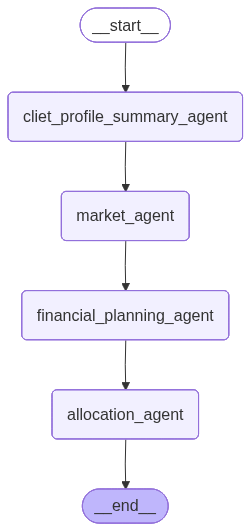

In [71]:
# tool nodes bound to specific tools
tools_client = ToolNode([getClientProfileSummary])
tools_market = ToolNode([getMarketAnalysis])
tools_finance = ToolNode([getFinancialPlanningRecommendations])
tools_alloc  = ToolNode([getInvestmentRecommendations])

# Build graph (NODES FIRST, then EDGES)
graph = StateGraph(AgentState)

graph.add_node("cliet_profile_summary_agent", cliet_profile_summary_agent)
graph.add_node("market_agent", market_agent)
graph.add_node("financial_planning_agent", financial_planning_agent)
graph.add_node("allocation_agent", allocation_agent)

graph.add_edge(START, "cliet_profile_summary_agent")
graph.add_edge("cliet_profile_summary_agent", "market_agent")
graph.add_edge("market_agent", "financial_planning_agent")
graph.add_edge("financial_planning_agent", "allocation_agent")
graph.add_edge("allocation_agent", END)

agent = graph.compile()
agent

In [97]:
if __name__ == "__main__":
    init_state = {
        "messages": [HumanMessage(content=
            "Analyze the personal finance data and provide the client summary profile. Then analyze the market data and recommend an allocation for the client."
        )]
    }

    final_state = None
    for step in agent.stream(init_state, stream_mode="values"):
        final_state = step
        msg = step["messages"][-1]
        try:
            msg.pretty_print()
        except Exception:
            print(msg)

    print("\n========= FINAL OUTPUT =========")

    print("client_profile:", final_state.get("client_profile"))
    print("financial_plan:", final_state.get("financial_plan"))
    print("Allocation:", final_state.get("allocation"))

    combined_json = {
        "client_profile": final_state.get("client_profile"),
        "financial_plan": final_state.get("financial_plan"),
        "allocation": final_state.get("allocation")
    }

    cluster_dict = final_state.get("client_profile")["cluster"]
    prompt_segment = list(cluster_dict.values())[0]


    # Save to a JSON file with indentation for readability
    with open(f"/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/report/output_{prompt_segment}.json", "w") as f:
        json.dump(combined_json, f, indent=4)

    print("Combined JSON saved as combined_output.json")

================================ Human Message =================================

Analyze the personal finance data and provide the client summary profile. Then analyze the market data and recommend an allocation for the client.
================================ Human Message =================================

Analyze the personal finance data and provide the client summary profile. Then analyze the market data and recommend an allocation for the client.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


================================ Human Message =================================

Analyze the personal finance data and provide the client summary profile. Then analyze the market data and recommend an allocation for the client.
Loading existing FAISS vector store...
DEBUG: Selected device: cuda


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


DEBUG: Model device after loading and adapters: cuda:0

MODEL RAW OUTPUT

================================ Human Message =================================

Analyze the personal finance data and provide the client summary profile. Then analyze the market data and recommend an allocation for the client.
Loading existing FAISS vector store...
DEBUG: Selected device: cuda


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


DEBUG: Model device after loading and adapters: cuda:0

MODEL RAW OUTPUT

================================ Human Message =================================

Analyze the personal finance data and provide the client summary profile. Then analyze the market data and recommend an allocation for the client.

========= FINAL OUTPUT =========
client_profile: {'client_profile': [{'name': 'Karthik Raghavan', 'monthly_income': 696.058427, 'monthly_expense_total': 4685.15153, 'actual_savings': 3.514498, 'budget_goal': 343, 'investment_amount': 4.550866, 'emergency_fund': 110.827995, 'credit_score': 484.26614, 'loan_payment': 316, 'debt_to_income_ratio': 0.454423, 'savings_rate': 0.0050491422324235435, 'subscription_services': 4, 'income_type': 'Salary', 'rent_or_mortgage': 3233}], 'cluster': {'2': 'Financially Stressed'}}
financial_plan: {'raw': '\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\